In [2]:
import pandas as pd
import numpy as np
import os
#import glob

## Importacion data

### Drive

In [ ]:
!ls -R "/content/drive/MyDrive/Tesis-resultados"

ls: cannot access '/content/drive/MyDrive/Tesis-resultados': No such file or directory


In [3]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount("/content/drive", force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [4]:
import os
BASE = "/content/drive/MyDrive/Tesis-resultados"
print("Contenido BASE:", os.listdir(BASE))

Contenido BASE: ['Encuestas.pdf', 'outputs', 'QF1515-25-27.pdf', 'Inferencia Datos Categóricos con anotaciones 2025.pdf', 'Inferencia Datos Numéricos2 con anotaciones 2025.pdf', 'Codificación para digitar resultados.pdf', 'Partes importante jsjsjs.pdf', 'resultados.xlsx', 'EDA.ipynb']


In [5]:
import glob

hits = glob.glob("/content/drive/MyDrive/**/resultados.xlsx", recursive=True)
hits

['/content/drive/MyDrive/Tesis-resultados (1)/resultados.xlsx',
 '/content/drive/MyDrive/Tesis-resultados/resultados.xlsx']

In [ ]:
paths = glob.glob("/content/drive/MyDrive/**/Tesis-resultados", recursive=True)
paths[:10]

['/content/drive/MyDrive/Tesis-resultados']

In [6]:
xls = glob.glob(f"{BASE}/*.xlsx")
xls
resultados_total = pd.read_excel(xls[0])
resultados_total['analfabeta'] = np.where(resultados_total['Sabe leer'] + resultados_total['Sabe escribir'] == 2, 0,1)
resultados_total.head()

,ID,EDAD,SEXO,ESCOLARIDAD,ETNIA,P1,P2,P3,P4,P5,P6,P7,P8,PUNTUACIÓN,Sabe leer,Sabe escribir,Lugar,analfabeta
0,1,30,1,1,4,1,0,2,0,1,0,2,1.0,NaN,0,0,San Yuyo,1
1,2,38,2,6,4,1,0,0,0,1,1,1,0.0,NaN,1,1,San Carlos Alzatate,0
2,3,38,2,1,4,1,0,1,0,0,1,1,1.0,NaN,0,0,San Carlos Alzatate,1
3,4,30,2,1,1,1,1,0,0,0,0,2,0.0,NaN,0,0,Monjas,1
4,5,24,2,2,4,2,0,1,0,1,1,0,2.0,NaN,1,1,San Yuyo,0


In [7]:
resultados_total.shape

(196, 18)

In [8]:
resultados_total.columns

Index(['ID', 'EDAD', 'SEXO', 'ESCOLARIDAD', 'ETNIA', 'P1', 'P2', 'P3', 'P4',
       'P5', 'P6', 'P7', 'P8', 'PUNTUACIÓN', 'Sabe leer', 'Sabe escribir',
       'Lugar', 'analfabeta'],
      dtype='object')

In [9]:
import os
BASE = "/content/drive/MyDrive/Tesis-resultados"
OUT = os.path.join(BASE, "outputs")
os.makedirs(OUT, exist_ok=True)

### Local

In [3]:
#resultados_Pre = pd.read_excel("C:\\Users\\rodri\\OneDrive\\Documentos\\EDA_Tesis\\resultados.xlsx", sheet_name="Pre")
# resultados_Pro = pd.read_excel("C:\\Users\\rodri\\OneDrive\\Documentos\\EDA_Tesis\\resultados.xlsx", sheet_name="Post")

resultados_Pre = pd.read_excel("C:\\Users\\rhernandez\\OneDrive - Generando Soluciones Anlalíticas S.A\\Documents\\EDA\\EDA_Tesis\\resultados.xlsx", sheet_name="Pre")
resultados_Pro = pd.read_excel("C:\\Users\\rhernandez\\OneDrive - Generando Soluciones Anlalíticas S.A\\Documents\\EDA\\EDA_Tesis\\resultados.xlsx", sheet_name="Post")

resultados_Pre['estado'] = 'pre'
resultados_Pro['estado'] = 'post'
resultados_total = pd.concat([resultados_Pre, resultados_Pro], ignore_index=True)
resultados_total['analfabeta'] = np.where(resultados_total['Sabe leer'] + resultados_total['Sabe escribir'] == 2, 0,1)
resultados_total.head()

,ID,EDAD,SEXO,ESCOLARIDAD,ETNIA,P1,P2,P3,P4,P5,P6,P7,P8,PUNTUACIÓN,Sabe leer,Sabe escribir,Lugar,estado,analfabeta
0,1,30,1,1,4,1,0,2,0,1,0,2,1.0,NaN,0,0,San Yuyo,pre,1
1,2,38,2,6,4,1,0,0,0,1,1,1,0.0,NaN,1,1,San Carlos Alzatate,pre,0
2,3,38,2,1,4,1,0,1,0,0,1,1,1.0,NaN,0,0,San Carlos Alzatate,pre,1
3,4,30,2,1,1,1,1,0,0,0,0,2,0.0,NaN,0,0,Monjas,pre,1
4,5,24,2,2,4,2,0,1,0,1,1,0,2.0,NaN,1,1,San Yuyo,pre,0


In [5]:
BASE = r"C:\Users\rhernandez\OneDrive - Generando Soluciones Anlalíticas S.A\Documents\EDA\EDA_Tesis"
#BASE = r"C:\Users\rodri\OneDrive\Documentos\EDA_Tesis"
OUT = os.path.join(BASE, "outputs")

# crea la carpeta outputs si no existe
os.makedirs(OUT, exist_ok=True)

print("BASE:", BASE)
print("OUT :", OUT)

BASE: C:\Users\rhernandez\OneDrive - Generando Soluciones Anlalíticas S.A\Documents\EDA\EDA_Tesis
OUT : C:\Users\rhernandez\OneDrive - Generando Soluciones Anlalíticas S.A\Documents\EDA\EDA_Tesis\outputs


In [ ]:
resultados_total['P2'] = np.where((resultados_total['P2'] == 0),1,0)
#resultados_total['P3'] = np.where((resultados_total['P3'] == 0) | (resultados_total['P3'] == 2), 0, 1)
resultados_total['P3'] = np.where((resultados_total['P3'] == 1), 1, 0)
resultados_total['P4'] = np.where((resultados_total['P4'] == 1),1,0)
resultados_total['P5'] = np.where((resultados_total['P5'] == 1),1,0)
resultados_total['P6'] = np.where((resultados_total['P6'] == 0),1,0)
resultados_total['P7'] = np.where((resultados_total['P7'] == 0),1,0)
resultados_total['P8'] = np.where((resultados_total['P8'] == 1),1,0)


resultados_total['resultado_final']= resultados_total[['P2','P3','P4','P5','P6','P7','P8']].sum(axis=1)

## Graficas

In [8]:
  import os
  import pandas as pd                                                                                                                                                                                    
  import seaborn as sns                                                                                                                                                                                  
  import matplotlib.pyplot as plt     

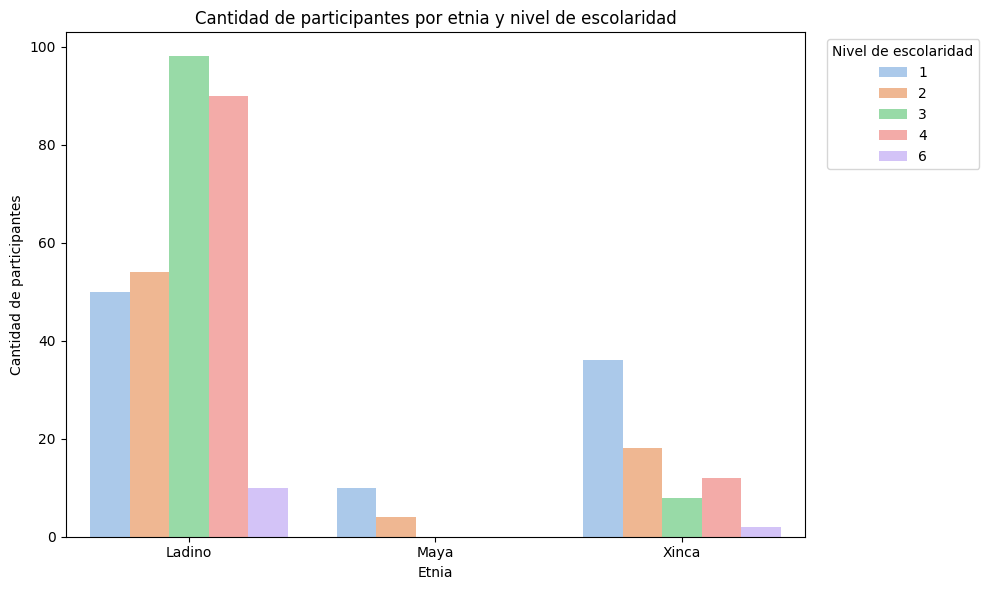

In [16]:
# Basado en la logica de tu EDA (mapeo de etnia 1,2,4 y orden fijo)
df_fix = resultados_total.copy()

etnia_map = {1: "Ladino", 2: "Maya", 4: "Xinca"}
order_etnia = ["Ladino", "Maya", "Xinca"]

df_fix["ETNIA_NUM"] = pd.to_numeric(df_fix["ETNIA"], errors="coerce")
df_fix["ETNIA_NOMBRE"] = df_fix["ETNIA_NUM"].map(etnia_map)
df_fix["ESCOLARIDAD_NUM"] = pd.to_numeric(df_fix["ESCOLARIDAD"], errors="coerce")

# Solo etnias validas y escolaridad no nula
df_plot = df_fix[df_fix["ETNIA_NOMBRE"].notna() & df_fix["ESCOLARIDAD_NUM"].notna()].copy()

# Cantidad de participantes por etnia y escolaridad
tabla = (
    df_plot.groupby(["ETNIA_NOMBRE", "ESCOLARIDAD_NUM"])
    .size()
    .reset_index(name="cantidad")
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=tabla,
    x="ETNIA_NOMBRE",
    y="cantidad",
    hue="ESCOLARIDAD_NUM",
    order=order_etnia,
    palette="pastel",
    errorbar=None
)

plt.title("Cantidad de participantes por etnia y nivel de escolaridad")
plt.xlabel("Etnia")
plt.ylabel("Cantidad de participantes")
plt.legend(title="Nivel de escolaridad", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig(os.path.join(OUT, "escolaridad_vs_etnia_pastel.png"), dpi=300, bbox_inches="tight")
plt.show()

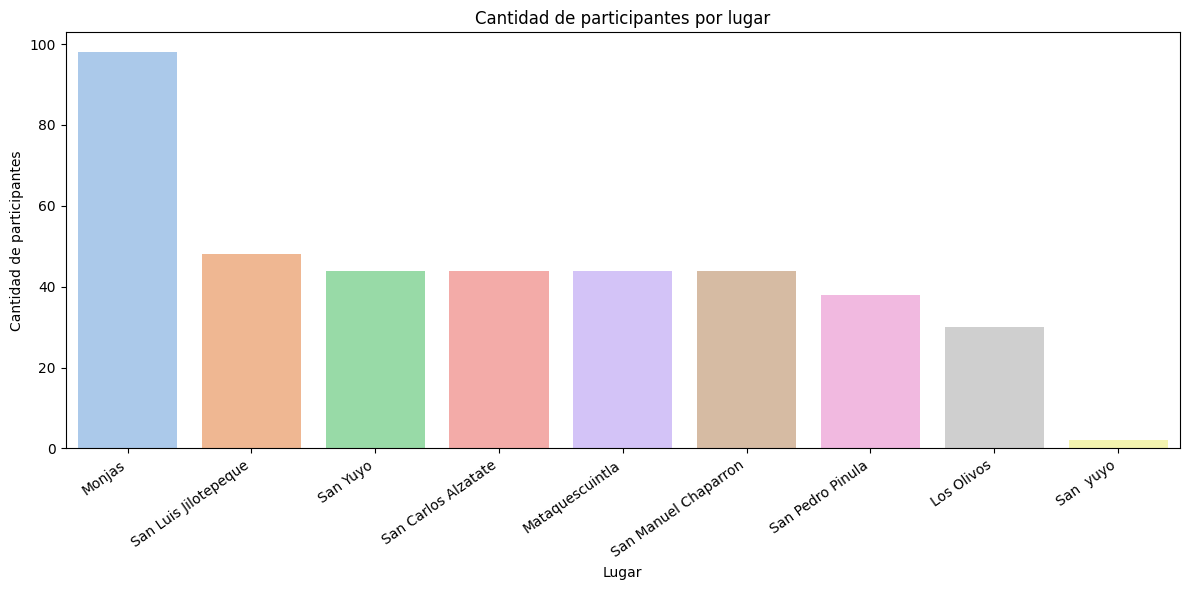

In [19]:
# Basado en la logica de tu EDA
df_fix = resultados_total.copy()
df_fix["Lugar"] = df_fix["Lugar"].astype(str).str.strip()

# Quitar vacios si existieran
df_lugar = df_fix[df_fix["Lugar"].notna() & (df_fix["Lugar"] != "")].copy()

# Ordenar por cantidad (de mayor a menor)
order_lugar = df_lugar["Lugar"].value_counts().index.tolist()

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_lugar,
    x="Lugar",
    order=order_lugar,
    palette="pastel"
)

plt.title("Cantidad de participantes por lugar")
plt.xlabel("Lugar")
plt.ylabel("Cantidad de participantes")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.savefig(
    os.path.join(OUT, "cantidad_participantes_por_lugar.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

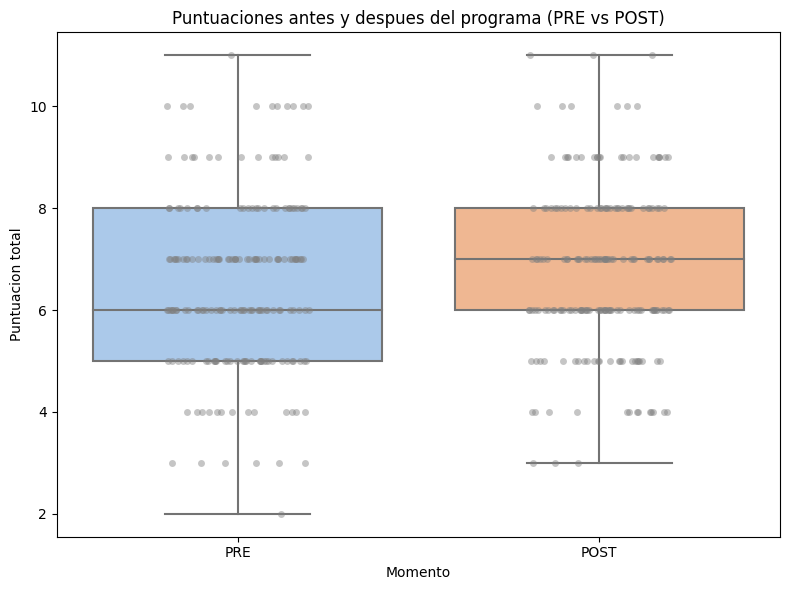

In [12]:
  # Basado en la logica de tu EDA
  df_fix = resultados_total.copy()                                                                                                                                                                       
  df_fix["estado"] = df_fix["estado"].astype(str).str.strip().str.upper()                                                                                                                                

  # Puntuacion total (igual que en tu notebook)                                                                                                                                                          
  score_cols = ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8"]                                                                                                                                          
  for c in score_cols:                                                                                                                                                                                   
      df_fix[c] = pd.to_numeric(df_fix[c], errors="coerce")                                                                                                                                              
                                                                                                                                                                                                         
  df_fix["puntuacion_total"] = df_fix[score_cols].sum(axis=1)                                                                                                                                            
                                                                                                                                                                                                         
  # Solo PRE y POST                                                                                                                                                                                      
  df_pp = df_fix[df_fix["estado"].isin(["PRE", "POST"])].copy()                                                                                                                                          
                                                                                                                                                                                                         
  plt.figure(figsize=(8, 6))                                                                                                                                                                             
  sns.boxplot(                                                                                                                                                                                           
      data=df_pp,                                                                                                                                                                                        
      x="estado",                                                                                                                                                                                        
      y="puntuacion_total",                                                                                                                                                                              
      order=["PRE", "POST"],                                                                                                                                                                             
      palette="pastel"                                                                                                                                                                                   
  )                                                                                                                                                                                                      
  sns.stripplot(                                                                                                                                                                                         
      data=df_pp,                                                                                                                                                                                        
      x="estado",                                                                                                                                                                                        
      y="puntuacion_total",                                                                                                                                                                              
      order=["PRE", "POST"],                                                                                                                                                                             
      color="gray",                                                                                                                                                                                      
      alpha=0.45,                                                                                                                                                                                        
      jitter=0.2                                                                                                                                                                                         
  )                                                                                                                                                                                                      
                                                                                                                                                                                                         
  plt.title("Puntuaciones antes y despues del programa (PRE vs POST)")                                                                                                                                   
  plt.xlabel("Momento")                                                                                                                                                                                  
  plt.ylabel("Puntuacion total")                                                                                                                                                                         
  plt.tight_layout()                                                                                                                                                                                     
                                                                                                                                                                                                         
  plt.savefig(os.path.join(OUT, "puntuaciones_pre_vs_post.png"), dpi=300, bbox_inches="tight")                                                                                                           
  plt.show()           

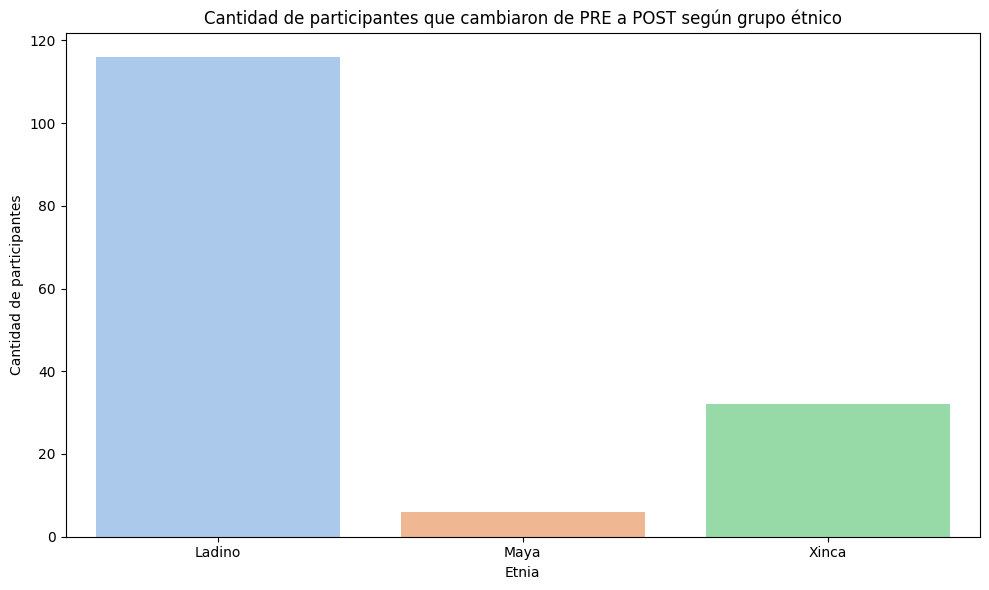

In [12]:
df_fix = resultados_total.copy()
df_fix["estado"] = df_fix["estado"].astype(str).str.strip().str.upper()

etnia_map = {1: "Ladino", 2: "Maya", 4: "Xinca"}
order_etnia = ["Ladino", "Maya", "Xinca"]

df_fix["ETNIA_NUM"] = pd.to_numeric(df_fix["ETNIA"], errors="coerce")
df_fix["ETNIA_NOMBRE"] = df_fix["ETNIA_NUM"].map(etnia_map)

# Puntaje total
score_cols = ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8"]
for c in score_cols:
    df_fix[c] = pd.to_numeric(df_fix[c], errors="coerce")

df_fix["resultado_final"] = df_fix[score_cols].sum(axis=1)

# Filtrar PRE/POST con etnia válida
df_pp = df_fix[
    df_fix["estado"].isin(["PRE", "POST"]) & df_fix["ETNIA_NOMBRE"].notna()
].copy()

# Ajusta "ID" al nombre real de tu columna identificadora
id_col = "ID"

# Dejar una fila por persona y estado
base = df_pp[[id_col, "ETNIA_NOMBRE", "estado", "resultado_final"]].drop_duplicates()

# Pasar PRE y POST a columnas
wide = (
    base.pivot_table(
        index=[id_col, "ETNIA_NOMBRE"],
        columns="estado",
        values="resultado_final",
        aggfunc="first"
    )
    .reset_index()
)

# Quedarse solo con quienes tienen PRE y POST
wide = wide.dropna(subset=["PRE", "POST"])

# Marcar si cambió
#wide["cambio"] = wide["POST"] != wide["PRE"]
wide["cambio"] = wide["POST"] > wide["PRE"]

# Contar cantidad de personas que cambiaron por etnia
cambio_df = (
    wide[wide["cambio"]]
    .groupby("ETNIA_NOMBRE", as_index=False)
    .size()
    .rename(columns={"size": "cantidad_personas_que_cambiaron"})
)

# Asegurar que salgan todas las etnias, aunque alguna tenga 0
cambio_df = (
    pd.DataFrame({"ETNIA_NOMBRE": order_etnia})
    .merge(cambio_df, on="ETNIA_NOMBRE", how="left")
    .fillna({"cantidad_personas_que_cambiaron": 0})
)

cambio_df["cantidad_personas_que_cambiaron"] = cambio_df["cantidad_personas_que_cambiaron"].astype(int)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=cambio_df,
    x="ETNIA_NOMBRE",
    y="cantidad_personas_que_cambiaron",
    order=order_etnia,
    palette="pastel",
    errorbar=None
)

plt.title("Cantidad de participantes que cambiaron de PRE a POST según grupo étnico")
plt.xlabel("Etnia")
plt.ylabel("Cantidad de participantes")
plt.tight_layout()

plt.savefig(
    os.path.join(OUT, "cantidad_personas_que_cambiaron_por_etnia_mejoran.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

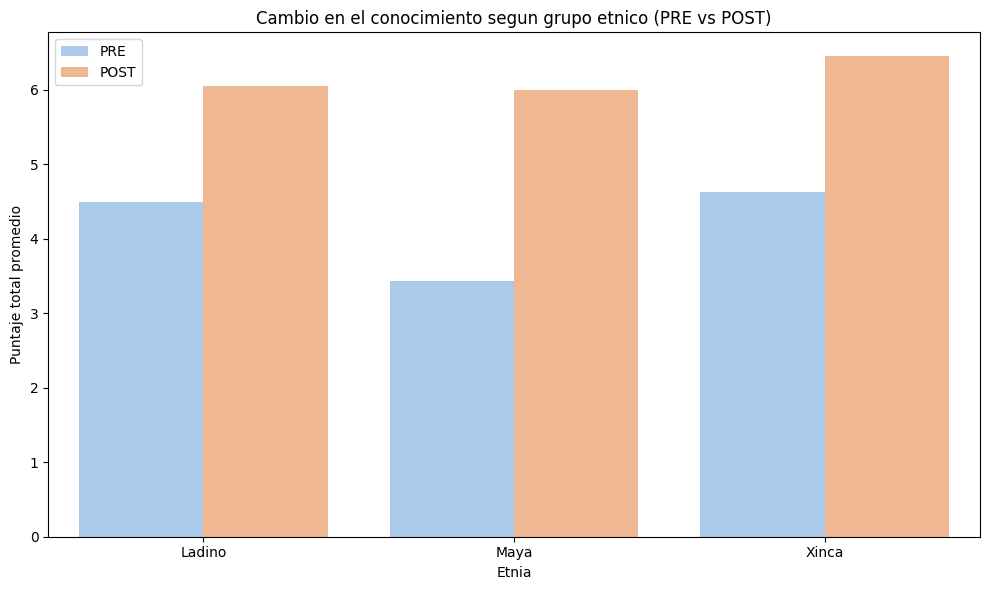

In [13]:
  df_fix = resultados_total.copy()                                                                                                                                                                       
  df_fix["estado"] = df_fix["estado"].astype(str).str.strip().str.upper()                                                                                                                                
                                                                                                                                                                                                         
  etnia_map = {1: "Ladino", 2: "Maya", 4: "Xinca"}                                                                                                                                                       
  order_etnia = ["Ladino", "Maya", "Xinca"]                                                                                                                                                              
                                                                                                                                                                                                         
  df_fix["ETNIA_NUM"] = pd.to_numeric(df_fix["ETNIA"], errors="coerce")                                                                                                                                  
  df_fix["ETNIA_NOMBRE"] = df_fix["ETNIA_NUM"].map(etnia_map)                                                                                                                                            

  # Puntaje total                                                                                                                                                                                        
  score_cols = ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8"]                                                                                                                                          
  for c in score_cols:                                                                                                                                                                                   
      df_fix[c] = pd.to_numeric(df_fix[c], errors="coerce")                                                                                                                                              
  df_fix["resultado_final"] = df_fix[score_cols].sum(axis=1)                                                                                                                                             
                                                                                                                                                                                                         
  # Solo PRE y POST con etnia valida                                                                                                                                                                     
  df_final = df_fix[df_fix["estado"].isin(["PRE", "POST"]) & df_fix["ETNIA_NOMBRE"].notna()].copy()                                                                                                      
                                                                                                                                                                                                         
  plt.figure(figsize=(10, 6))                                                                                                                                                                            
  sns.barplot(                                                                                                                                                                                           
      data=df_final,                                                                                                                                                                                     
      x="ETNIA_NOMBRE",                                                                                                                                                                                  
      y="resultado_final",                                                                                                                                                                               
      hue="estado",                                                                                                                                                                                      
      order=order_etnia,                                                                                                                                                                                 
      hue_order=["PRE", "POST"],
      palette="pastel",                                                                                                                                                                                  
      errorbar=None,                                                                                                                                                                                     
      capsize=0.15                                                                                                                                                                                       
  )                                                                                                                                                                                                      
                                                                                                                                                                                                         
  plt.title("Cambio en el conocimiento segun grupo etnico (PRE vs POST)")                                                                                                                                
  plt.xlabel("Etnia")                                                                                                                                                                                    
  plt.ylabel("Puntaje total promedio")                                                                                                                                                     
  plt.legend(title="")                                                                                                                                                                                   
  plt.tight_layout()                            
                                                                                                                   
                                                                                                                                                                                                         
  plt.savefig(os.path.join(OUT, "cambio_conocimiento_pre_vs_post_por_etnia.png"), dpi=300, bbox_inches="tight")                                                                                          
  plt.show()    

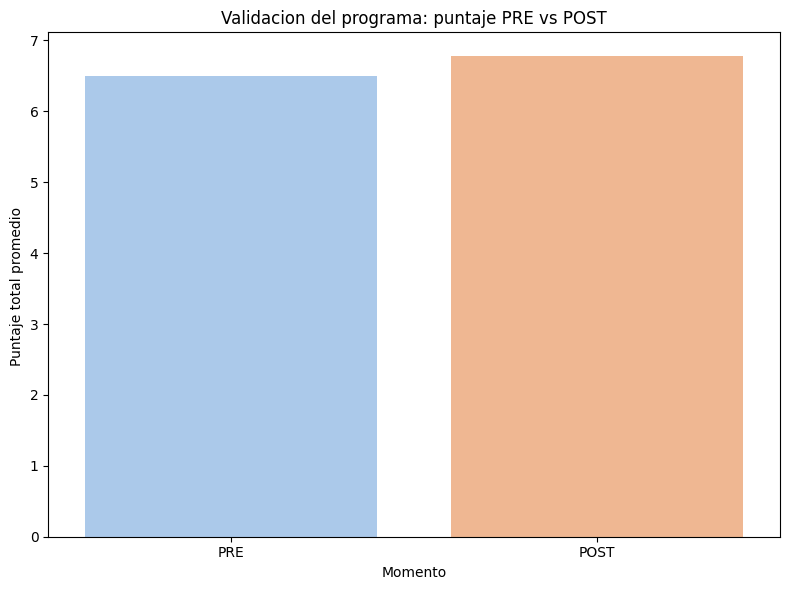

In [11]:
  df_fix = resultados_total.copy()                                                                                                                                                                       
  df_fix["estado"] = df_fix["estado"].astype(str).str.strip().str.upper()                                                                                                                                
                                                                                                                                                                                                         
  score_cols = ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8"]                                                                                                                                          
  for c in score_cols:                                                                                                                                                                                   
      df_fix[c] = pd.to_numeric(df_fix[c], errors="coerce")                                                                                                                                              
                                                                                                                                                                                                         
  df_fix["puntaje_total"] = df_fix[score_cols].sum(axis=1)                                                                                                                                               
  df_pp = df_fix[df_fix["estado"].isin(["PRE", "POST"])].copy()                                                                                                                                          
                                                                                                                                                                                                         
  # Resumen para barra (media y EE)                                                                                                                                                                      
  resumen = (                                                                                                                                                                                            
      df_pp.groupby("estado", as_index=False)["puntaje_total"]                                                                                                                                           
      .agg(media="mean", n="count", sd="std")                                                                                                                                                            
  )                                                                                                                                                                                                      
  resumen["ee"] = resumen["sd"] / resumen["n"]**0.5                                                                                                                                                      
  orden = ["PRE", "POST"]                                                                                                                                                                                
                                                                                                                                                                                                         
  plt.figure(figsize=(8, 6))                                                                                                                                                                             
  ax = sns.barplot(                                                                                                                                                                                      
      data=resumen,                                                                                                                                                                                      
      x="estado",                                                                                                                                                                                        
      y="media",                                                                                                                                                                                         
      hue="estado",                                                                                                                                                                                      
      order=orden,                                                                                                                                                                                       
      hue_order=orden,                                                                                                                                                                                   
      palette="pastel",                                                                                                                                                                                  
      errorbar=None,                                                                                                                                                                                     
      dodge=False                                                                                                                                                                                        
  )                                                                                                                                                                                                      
                                                                                                                                                                                                         
                                                                                                                                                                                                
                                                                                                                                                                                                         
  plt.title("Validacion del programa: puntaje PRE vs POST")                                                                                                                                              
  plt.xlabel("Momento")                                                                                                                                                                                  
  plt.ylabel("Puntaje total promedio ")
  ax.get_legend().remove()                                                                                                                                                                               
  plt.tight_layout()                                                                                                                                                                                     
                                                                                                                                                                                                         
  plt.savefig(os.path.join(OUT, "validacion_programa_pre_vs_post_barras.png"), dpi=300, bbox_inches="tight")                                                                                             
  plt.show()         

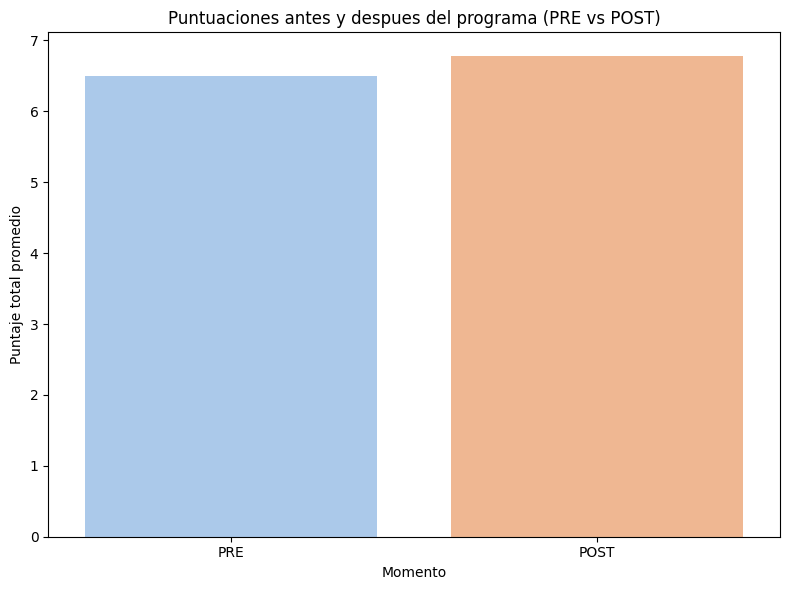

In [21]:
  df_fix = resultados_total.copy()
  df_fix["estado"] = df_fix["estado"].astype(str).str.strip
  import os
  import pandas as pd
  import seaborn as sns
  import matplotlib.pyplot as plt

  df_fix = resultados_total.copy()
  df_fix["estado"] = df_fix["estado"].astype(str).str.strip().str.upper()

  # Puntaje total
  score_cols = ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8"]
  for c in score_cols:
      df_fix[c] = pd.to_numeric(df_fix[c], errors="coerce")
  df_fix["puntaje_total"] = df_fix[score_cols].sum(axis=1)

  # Solo PRE/POST                                                                                                                                                                                        
  df_pp = df_fix[df_fix["estado"].isin(["PRE", "POST"])].copy()                                                                                                                                          
                                                                                                                                                                                                         
  plt.figure(figsize=(8, 6))                                                                                                                                                                             
  sns.barplot(                                                                                                                                                                                           
      data=df_pp,                                                                                                                                                                                        
      x="estado",                                                                                                                                                                                        
      y="puntaje_total",                                                                                                                                                                                 
      order=["PRE", "POST"],                                                                                                                                                                             
      hue="estado",                                                                                                                                                                                      
      hue_order=["PRE", "POST"],                                                                                                                                                                         
      palette="pastel",                                                                                                                                                                                  
      errorbar=None,   # sin barras de error                                                                                                                                                             
      dodge=False                                                                                                                                                                                        
  )                                                                                                                                                                                                      
                                                                                                                                                                                                         
  plt.title("Puntuaciones antes y despues del programa (PRE vs POST)")                                                                                                                                   
  plt.xlabel("Momento")                                                                                                                                                                                  
  plt.ylabel("Puntaje total promedio")                                                                                                                                                                   
  plt.legend([], [], frameon=False)  # oculta leyenda duplicada
  plt.tight_layout()                                                                                                                                                                                     
                                                                                                                                                                                                         
  plt.savefig(os.path.join(OUT, "puntuaciones_pre_vs_post_barras_sin_error.png"), dpi=300, bbox_inches="tight")                                                                                          
  plt.show()

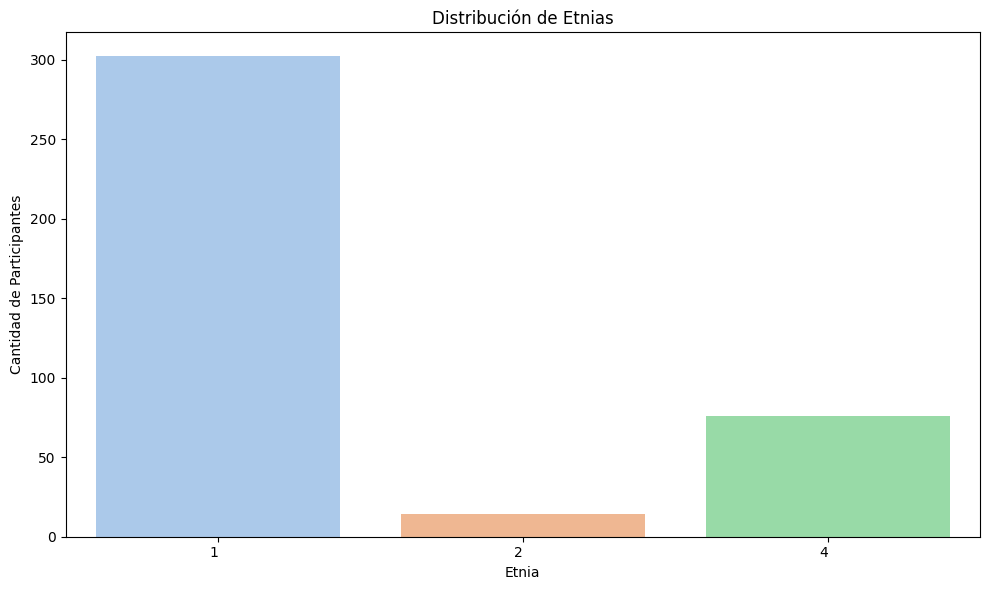

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.figure(figsize=(10, 6))
sns.countplot(data=resultados_total, x='ETNIA', palette='pastel')
plt.title('Distribución de Etnias')
plt.xlabel('Etnia')
plt.ylabel('Cantidad de Participantes')

plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUT, "etnia_distribution_count.png"), dpi=300, bbox_inches="tight")
plt.show()

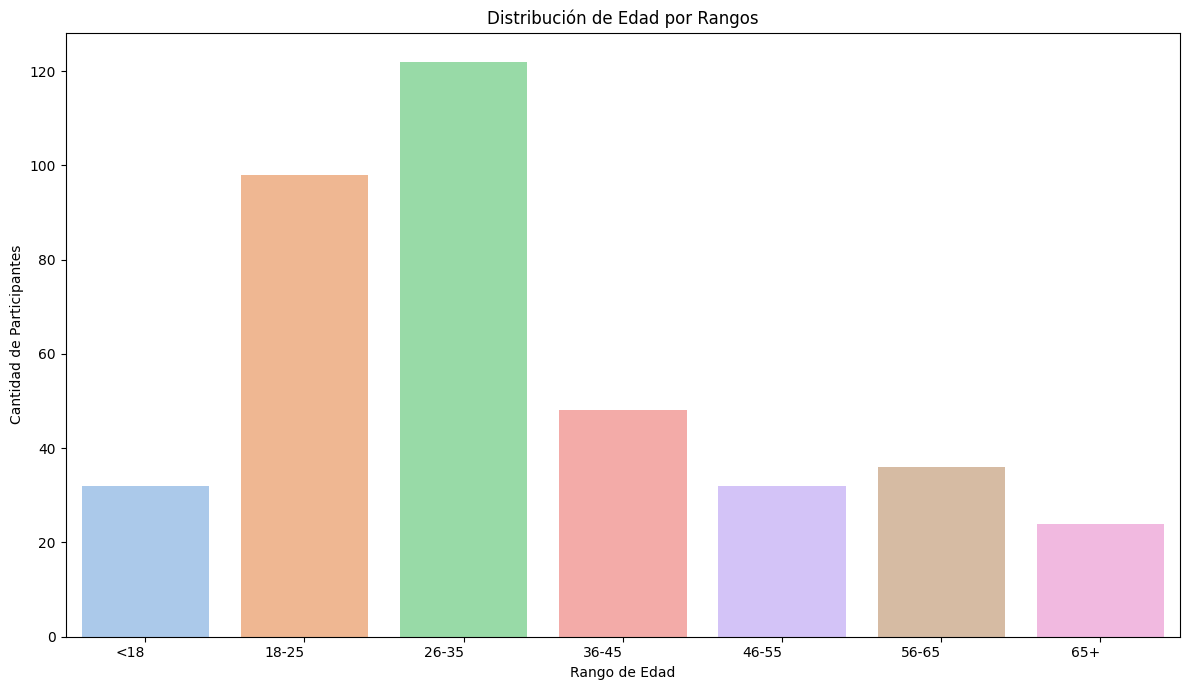

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the age bins based on user request
bins = [0, 17, 25, 35, 45, 55, 65, 100] # Adjust upper bound as needed for your data
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']

# Create a new column with age ranges for easier plotting
resultados_total['Rango_Edad'] = pd.cut(resultados_total['EDAD'], bins=bins, labels=labels, right=False)
plt.figure(figsize=(12, 7))
sns.countplot(data=resultados_total, x='Rango_Edad', palette='pastel', order=labels)
plt.title('Distribución de Edad por Rangos')
plt.xlabel('Rango de Edad')
plt.ylabel('Cantidad de Participantes')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUT, "edad_histograma_rangos.png"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
resultados_total.shape

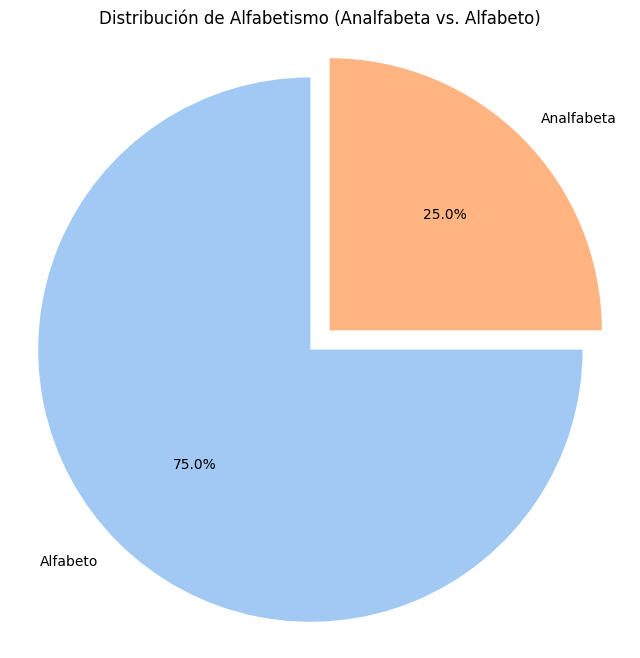

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

literacy_counts = resultados_total['analfabeta'].value_counts()

labels = ['Alfabeto' if x == 0 else 'Analfabeta' for x in literacy_counts.index]
colors = sns.color_palette('pastel')[0:len(literacy_counts)]

plt.figure(figsize=(8, 8))
plt.pie(literacy_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=[0.05]*len(literacy_counts))
plt.title('Distribución de Alfabetismo (Analfabeta vs. Alfabeto)')
plt.axis('equal')
plt.savefig(os.path.join(OUT, "analfabetismo_pie_chart.png"), dpi=300, bbox_inches="tight")
plt.show()

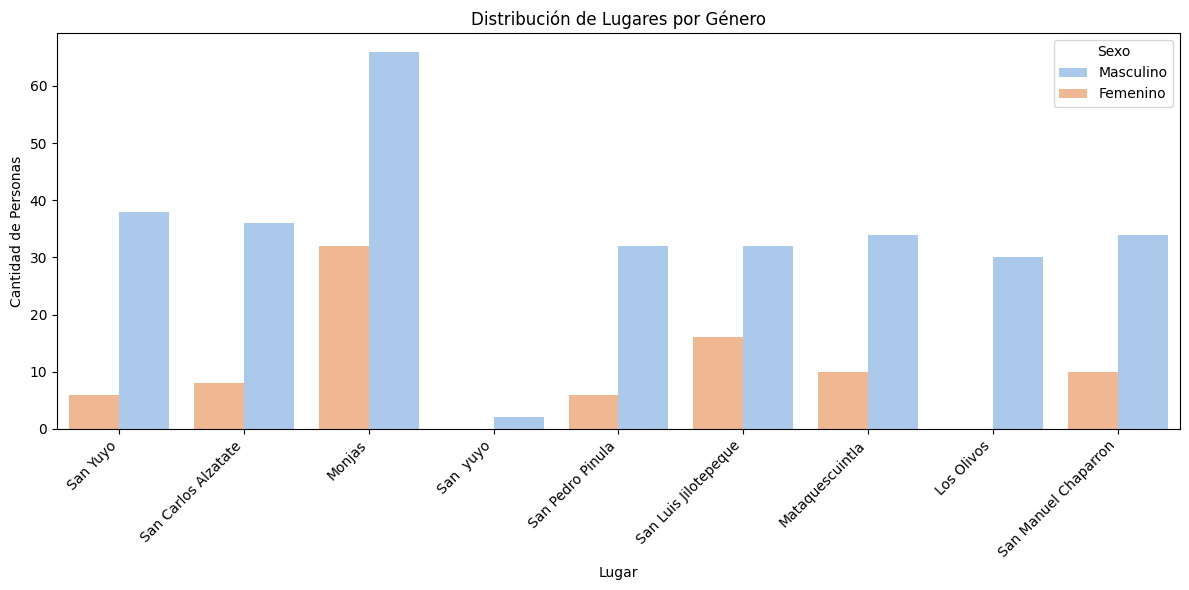

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=resultados_total, x='Lugar', hue='SEXO', palette='pastel')
plt.title('Distribución de Lugares por Género')
plt.xlabel('Lugar')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sexo', labels=['Masculino', 'Femenino'])
plt.tight_layout()
plt.savefig(os.path.join(OUT, "genero_lugar_count.png"), dpi=300, bbox_inches="tight")
pal = sns.color_palette("pastel", 2)

palette_invertido = {
    1: pal[1],  # hombre
    2: pal[0],  # mujer
}

ax = sns.countplot(
    data=resultados_total,
    x="Lugar",
    hue="SEXO",
    palette=palette_invertido
)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Masculino", "Femenino"], title="Sexo")
plt.show()

## Pre y post

In [ ]:
# resultados_total['P2'] = np.where((resultados_total['P2'] == 0),1,0)
# #resultados_total['P3'] = np.where((resultados_total['P3'] == 0) | (resultados_total['P3'] == 2), 0, 1)
# resultados_total['P3'] = np.where((resultados_total['P3'] == 1), 1, 0)
# resultados_total['P4'] = np.where((resultados_total['P4'] == 1),1,0)
# resultados_total['P5'] = np.where((resultados_total['P5'] == 1),1,0)
# resultados_total['P6'] = np.where((resultados_total['P6'] == 0),1,0)
# resultados_total['P7'] = np.where((resultados_total['P7'] == 0),1,0)
# resultados_total['P8'] = np.where((resultados_total['P8'] == 1),1,0)


# resultados_total['resultado_final']= resultados_total[['P2','P3','P4','P5','P6','P7','P8']].sum(axis=1)

In [50]:
resultados_total[resultados_total["estado"] == "pre"].describe()

,ID,EDAD,SEXO,ESCOLARIDAD,ETNIA,P1,P2,P3,P4,P5,P6,P7,P8,PUNTUACIÓN,Sabe leer,Sabe escribir,analfabeta,resultado_final
count,196.00000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,0.0,196.000000,196.000000,196.000000,196.000000
mean,98.50000,33.744898,1.775510,2.668367,1.617347,1.637755,0.397959,0.607143,0.474490,0.479592,0.418367,0.214286,0.255102,NaN,0.755102,0.750000,0.250000,2.846939
std,56.72448,15.560510,0.418314,1.267835,1.186032,0.892363,0.490730,0.489636,0.500628,0.500863,0.494554,0.411377,0.437035,NaN,0.431128,0.434122,0.434122,1.353832
min,1.00000,11.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
25%,49.75000,22.000000,2.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,0.750000,0.000000,2.000000
50%,98.50000,29.000000,2.000000,3.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,0.000000,3.000000
75%,147.25000,42.250000,2.000000,4.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,NaN,1.000000,1.000000,0.250000,4.000000
max,196.00000,79.000000,2.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,1.000000,1.000000,6.000000


In [58]:
suma_p2_p8 = (
      resultados_total.loc[resultados_total["estado"] == "pre", "P2":"P8"]
      .sum()
  )

print(suma_p2_p8)

P2     78
P3    119
P4     93
P5     94
P6     82
P7     42
P8     50
dtype: int64


In [33]:
resultados_total.head()

,ID,EDAD,SEXO,ESCOLARIDAD,ETNIA,P1,P2,P3,P4,P5,P6,P7,P8,PUNTUACIÓN,Sabe leer,Sabe escribir,Lugar,estado,analfabeta,resultado_final
0,1,30,1,1,4,1,1,0,0,1,1,0,1,NaN,0,0,San Yuyo,pre,1,4
1,2,38,2,6,4,1,1,1,0,1,0,1,0,NaN,1,1,San Carlos Alzatate,pre,0,4
2,3,38,2,1,4,1,1,0,0,0,0,1,1,NaN,0,0,San Carlos Alzatate,pre,1,3
3,4,30,2,1,1,1,0,1,0,0,1,0,0,NaN,0,0,Monjas,pre,1,2
4,5,24,2,2,4,2,1,0,0,1,0,0,0,NaN,1,1,San Yuyo,pre,0,2


In [59]:
tabla_media_estado = (
    resultados_total.assign(
        estado=resultados_total["estado"].astype(str).str.strip().str.lower(),
        resultado_final=pd.to_numeric(resultados_total["resultado_final"], errors="coerce")
    )
    .groupby("estado", as_index=False)["resultado_final"]
    .mean()
    .rename(columns={"resultado_final": "media_resultado_final"})
)

print(tabla_media_estado)

  estado  media_resultado_final
0   post               4.469388
1    pre               2.846939


In [60]:
tabla_media_estado = (
    resultados_total.assign(
        estado=resultados_total["estado"].astype(str).str.strip().str.lower(),
        resultado_final=pd.to_numeric(resultados_total["resultado_final"], errors="coerce")
    )
    .groupby("estado", as_index=False)["resultado_final"]
    .sum()
    .rename(columns={"resultado_final": "media_resultado_final"})
)

print(tabla_media_estado)

  estado  media_resultado_final
0   post                    876
1    pre                    558


In [38]:
resultados_total['ETNIA'].unique()

array([4, 1, 2])

In [ ]:
resultados_total[resultados_total['ID'] == 1]
#

,ID,EDAD,SEXO,ESCOLARIDAD,ETNIA,P1,P2,P3,P4,P5,P6,P7,P8,PUNTUACIÓN,Sabe leer,Sabe escribir,Lugar,estado,analfabeta,resultado_final
0,1,30,1,1,4,1,0,2,0,1,0,2,1.0,NaN,0,0,San Yuyo,pre,1,7.0
196,1,30,1,1,4,1,0,2,1,0,0,0,1.0,NaN,0,0,San Yuyo,post,1,5.0


In [ ]:
# -Distribución por distrito/servicio de salud.
# -Análisis de conocimiento
# -Gráficas comparativas PRE vs POST por preguntas clave:
#      P4 (prevención de diarrea)
#      P6 (uso de antibióticos sin receta)P7 (antibiótico en resfriado)
#      P8 (uso de ibuprofeno/aspirina en dengue)
# -Gráfica de diferencia porcentual de respuestas correctas PRE vs POST.
# -Tabla comparativa general PRE vs POST por distrito.
# -Consolidado general de los servicios de salud.

# Pertinencia cultural
# gráfica Comparación PRE vs POST por grupo étnico.
# Tabla cruzada Etnia × Respuesta correcta (preguntas clave).
# tabla/ gráficaValidación del programa educativo por grupo étnico.
# tabla Validación del programa

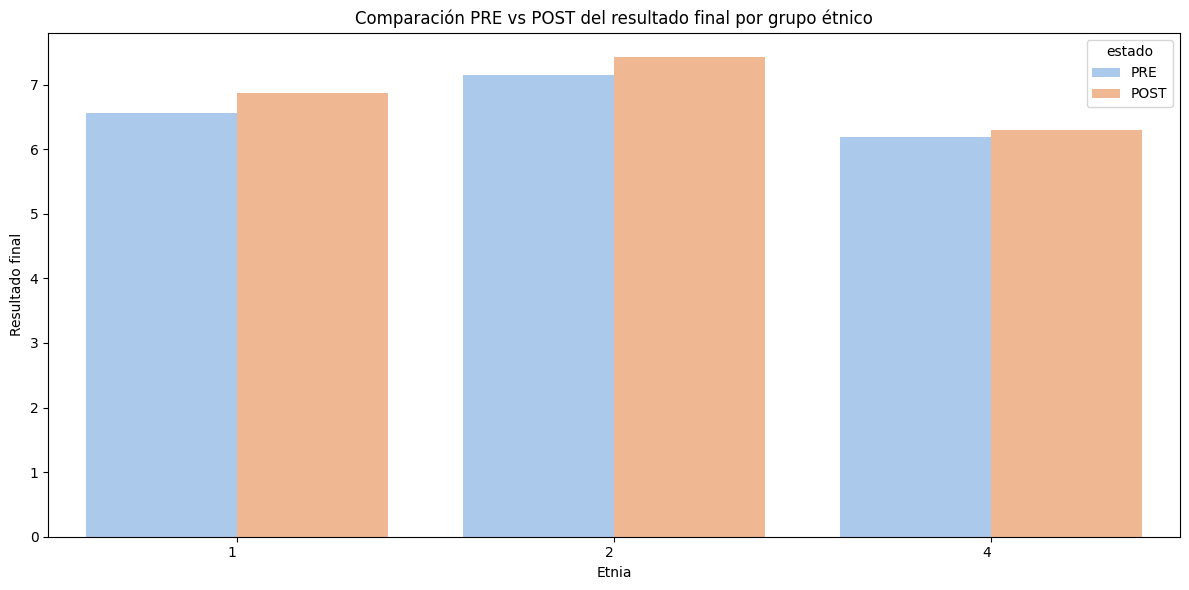

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

df = resultados_total.copy()
df["estado"] = df["estado"].astype(str).str.strip().str.upper()
df["resultado_final"] = pd.to_numeric(df["resultado_final"], errors="coerce")
df = df[df["estado"].isin(["PRE", "POST"])]

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df,
    x="ETNIA",
    y="resultado_final",
    hue="estado",
    palette="pastel",
    order=sorted(df["ETNIA"].dropna().unique()),
    hue_order=["PRE", "POST"],
    errorbar=None,     # si te da error, mira el bloque de abajo
    capsize=0.15
)

plt.title("Comparación PRE vs POST del resultado final por grupo étnico")
plt.xlabel("Etnia")
plt.ylabel("Resultado final")
plt.xticks(rotation=0, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "resultado_final_pre_vs_post_por_etnia.png"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# EE = Error Estándar (standard error).
# En la gráfica “media ± EE”, las barras muestran el promedio de resultado_final y las “patitas” (error bars) muestran qué tan precisa es esa media.
# EE = desviación estándar / √n
# Si EE es pequeño, la media está estimada con más precisión.
# Si EE es grande, hay más variabilidad y/o pocos datos.
# Ojo: EE no es lo mismo que desviación estándar (DE).
# DE = qué tanto varían los datos individuales.
# EE = qué tanto puede variar la media si repitieras el muestreo.
# Si preferís que las barras muestren DE (más intuitivo a veces), te cambio el código a errorbar="sd" (o equivalente).

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

import seaborn as sns  



QUESTIONS = ["P1","P2","P3","P4","P5","P6","P7","P8"]


AFIRMATIVO = {
    "P1": [1],  # Centro de salud
    "P2": [1],  # Sí
    "P3": [1],  # Sí (A veces y No cuentan como negativo)
    "P4": [1],  # Sí
    "P5": [1],  # Sí
    "P6": [0],  # No
    "P7": [0],  # No
    "P8": [0],  # No
}

def tabla_afirmativo_negativo(df_in: pd.DataFrame, questions, afirm_map) -> pd.DataFrame:
    df = df_in.copy()
    df["estado"] = df["estado"].astype(str).str.strip().str.upper()
    df = df[df["estado"].isin(["PRE","POST"])]

    for q in questions:
        if q in df.columns:
            df[q] = pd.to_numeric(df[q], errors="coerce")

    col_labels = [str(i) for i in range(1, len(questions)+1)]

    filas = {
        "pre-encuesta Afirmativo": [],
        "post-encuesta Afirmativo": [],
        "pre-encuesta Negativo": [],
        "post-encuesta negativo": [],
    }

    for q in questions:
        afirm = set(afirm_map.get(q, []))

        pre = df[df["estado"]=="PRE"][q].dropna()
        post = df[df["estado"]=="POST"][q].dropna()

        pre_af = int(pre.isin(afirm).sum())
        pre_ng = int((~pre.isin(afirm)).sum())

        post_af = int(post.isin(afirm).sum())
        post_ng = int((~post.isin(afirm)).sum())

        filas["pre-encuesta Afirmativo"].append(pre_af)
        filas["post-encuesta Afirmativo"].append(post_af)
        filas["pre-encuesta Negativo"].append(pre_ng)
        filas["post-encuesta negativo"].append(post_ng)

    tabla = pd.DataFrame(filas, index=col_labels).T
    return tabla

tabla = tabla_afirmativo_negativo(resultados_total, QUESTIONS, AFIRMATIVO)
print(tabla)

out_xlsx = os.path.join(OUT, "tabla_afirmativo_negativo.xlsx")
tabla.to_excel(out_xlsx, sheet_name="Tabla", index=True)
print("Guardado:", out_xlsx)

vals = tabla.values
series = tabla.index.tolist()
x = np.arange(tabla.shape[1])
w = 0.18


fig, ax = plt.subplots(figsize=(10, 5))

for i, name in enumerate(series):
    ax.bar(x + (i - 1.5)*w, vals[i], width=w, label=name)

ax.set_xticks(x)
ax.set_xticklabels(tabla.columns.tolist())
ax.set_ylim(0, max(vals.flatten()) * 1.15)
bar_containers = []
for i, name in enumerate(series):
    bc = ax.bar(
        x + (i - 1.5)*w,
        vals[i],
        width=w,
        label=name,
        color=colors[i]
    )
    bar_containers.append(bc)
handles = [bc[0] for bc in bar_containers]
ax.legend(
    handles, series,
    loc="upper left",
    bbox_to_anchor=(-0.30, 0.25),
    borderaxespad=0,
    fontsize=8
)

colors = sns.color_palette("pastel", n_colors=len(series))

for i, name in enumerate(series):
    ax.bar(
        x + (i - 1.5)*w,
        vals[i],
        width=w,
        label=name,
        color=colors[i]
    )

tbl = ax.table(
    cellText=vals,
    rowLabels=series,
    colLabels=tabla.columns.tolist(),
    cellLoc="center",
    rowLoc="center",
    loc="bottom",
    bbox=[0.0, -0.45, 1.0, 0.35]
)

plt.subplots_adjust(bottom=0.35)
out_png = os.path.join(OUT, "afirmativo_negativo_tabla_pastel.png")
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("PNG guardado:", out_png)

ModuleNotFoundError: No module named 'matplotlib'

In [61]:
import pandas as pd
import numpy as np
import os

QUESTIONS = ["P1","P2","P3","P4","P5","P6","P7","P8"]

# Afirmativo por pregunta (ajustá si cambia tu definición)
AFIRMATIVO = {
    "P1": [1],
    "P2": [1],
    "P3": [1],
    "P4": [1],
    "P5": [1],
    "P6": [0],
    "P7": [0],
    "P8": [0],
}

def resumen_tabla_pre_post(df_in: pd.DataFrame, questions, afirm_map) -> pd.DataFrame:
    df = df_in.copy()
    df["estado"] = df["estado"].astype(str).str.strip().str.upper()
    df = df[df["estado"].isin(["PRE", "POST"])]

    for q in questions:
        if q in df.columns:
            df[q] = pd.to_numeric(df[q], errors="coerce")

    def fmt(cnt, total):
        pct = (cnt / total * 100) if total > 0 else 0
        return f"{int(cnt)} ({pct:.0f}%)"

    rows = []
    for i, q in enumerate(questions, start=1):
        afirm = set(afirm_map.get(q, []))

        pre = df[df["estado"] == "PRE"][q].dropna()
        post = df[df["estado"] == "POST"][q].dropna()

        pre_af = int(pre.isin(afirm).sum())
        pre_ng = int((~pre.isin(afirm)).sum())
        post_af = int(post.isin(afirm).sum())
        post_ng = int((~post.isin(afirm)).sum())

        pre_tot = pre_af + pre_ng
        post_tot = post_af + post_ng

        rows.append({
            "No.": i,
            "Preguntas": f"Pregunta {i}?",
            "Pre-encuesta Respuesta Afirmativa": fmt(pre_af, pre_tot),
            "Pre-encuesta Respuesta Negativa":  fmt(pre_ng, pre_tot),
            "Post-encuesta Respuesta Afirmativa": fmt(post_af, post_tot),
            "Post-encuesta Respuesta Negativa":  fmt(post_ng, post_tot),
        })

    return pd.DataFrame(rows)

tabla_final = resumen_tabla_pre_post(resultados_total, QUESTIONS, AFIRMATIVO)
tabla_final

,No.,Preguntas,Pre-encuesta Respuesta Afirmativa,Pre-encuesta Respuesta Negativa,Post-encuesta Respuesta Afirmativa,Post-encuesta Respuesta Negativa
0,1,Pregunta 1?,114 (58%),82 (42%),112 (57%),84 (43%)
1,2,Pregunta 2?,78 (40%),118 (60%),88 (45%),108 (55%)
2,3,Pregunta 3?,119 (61%),77 (39%),118 (60%),78 (40%)
3,4,Pregunta 4?,93 (47%),103 (53%),163 (83%),33 (17%)
4,5,Pregunta 5?,94 (48%),102 (52%),156 (80%),40 (20%)
5,6,Pregunta 6?,114 (58%),82 (42%),119 (61%),77 (39%)
6,7,Pregunta 7?,154 (79%),42 (21%),57 (29%),139 (71%)
7,8,Pregunta 8?,146 (74%),50 (26%),61 (31%),135 (69%)


In [62]:
out_path = os.path.join(OUT, "tabla_resumen_pre_post.xlsx")
tabla_final.to_excel(out_path, index=False)
print("Guardado:", out_path)

Guardado: C:\Users\rodri\OneDrive\Documentos\EDA_Tesis\outputs\tabla_resumen_pre_post.xlsx


In [13]:
resultados_total['P7'] = np.where((resultados_total['P7'] == 2) | (resultados_total['P7'] == 0), 0, 1)

C:\Users\rhernandez\AppData\Local\Temp\ipykernel_14548\91782522.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


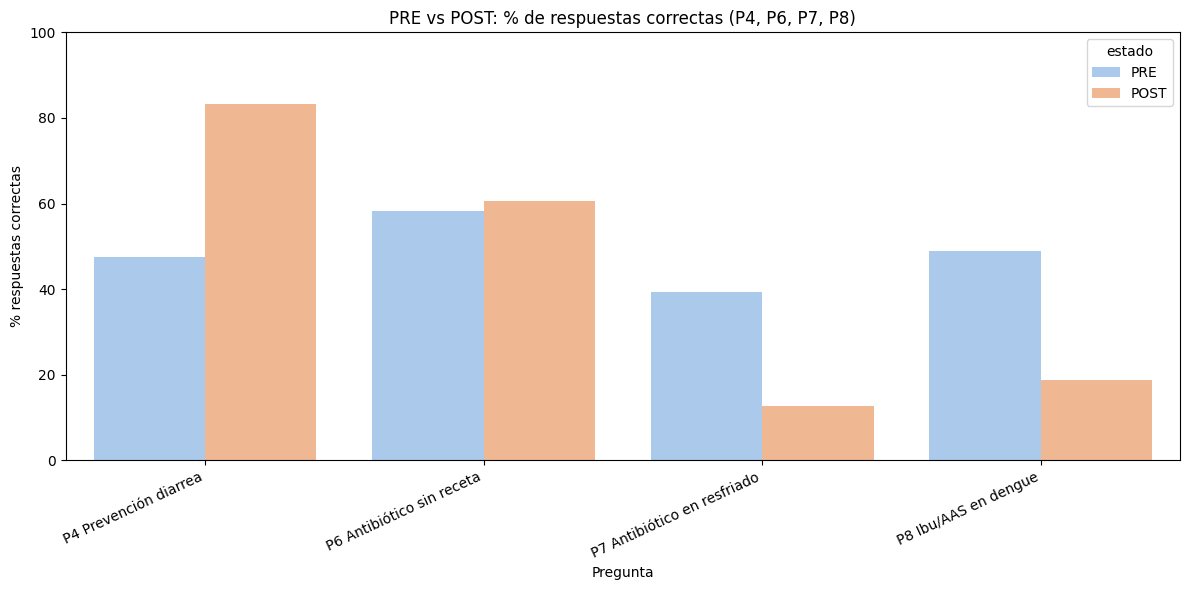

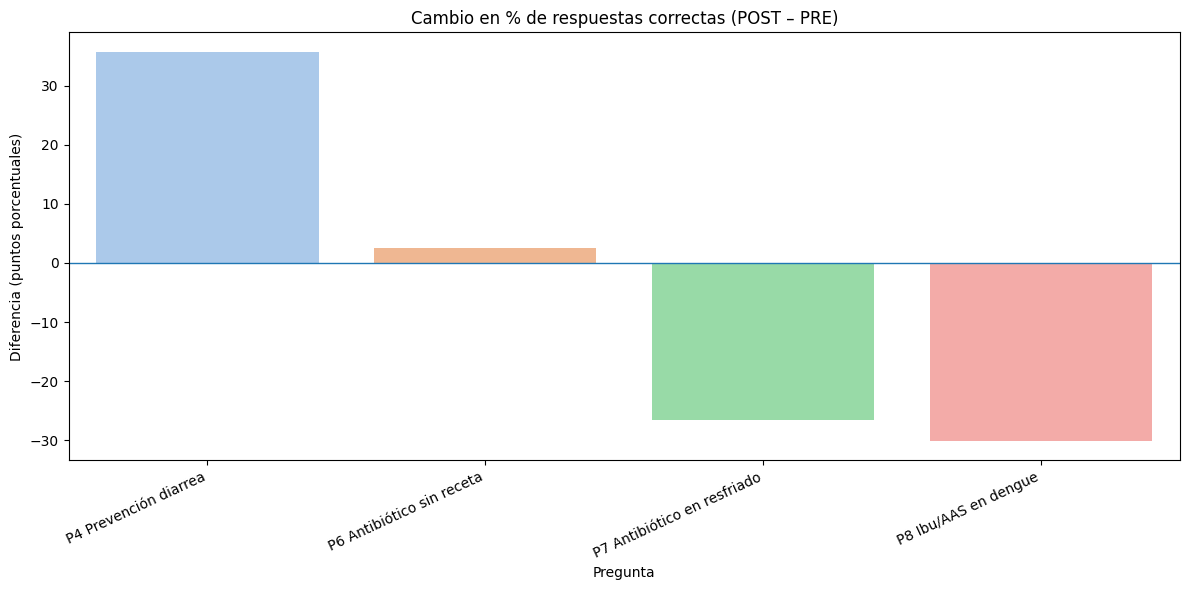

In [52]:
# --- Config ---
questions = ["P4", "P6", "P7", "P8"]
q_labels = {
    "P4": "P4 Prevención diarrea",
    "P6": "P6 Antibiótico sin receta",
    "P7": "P7 Antibiótico en resfriado",
    "P8": "P8 Ibu/AAS en dengue"
}

df = resultados_total.copy()
df["estado"] = df["estado"].astype(str).str.strip().str.upper()
df = df[df["estado"].isin(["PRE", "POST"])]

# Asegurar numérico
for q in questions:
    df[q] = pd.to_numeric(df[q], errors="coerce")

# --- Definir "correcto" por pregunta ---
# Opción A (por defecto): correcto = valor máximo observado (útil si 0/1/2 es puntuación)
correct_key = df[questions].max().to_dict()

# --- Long format + % correcto ---
long = df.melt(id_vars=["estado"], value_vars=questions, var_name="pregunta", value_name="respuesta")
long["key"] = long["pregunta"].map(correct_key)
long["correcta"] = (long["respuesta"] == long["key"]).astype(float)

grp = (long.groupby(["pregunta", "estado"])["correcta"]
       .mean()
       .reset_index())
grp["porc_correctas"] = grp["correcta"] * 100
grp["pregunta_lbl"] = grp["pregunta"].map(q_labels)

order_lbl = [q_labels[q] for q in questions]

# =========================
# 1) PRE vs POST por pregunta
# =========================
plt.figure(figsize=(12, 6))
sns.barplot(
    data=grp,
    x="pregunta_lbl",
    y="porc_correctas",
    hue="estado",
    palette="pastel",
    order=order_lbl,
    hue_order=["PRE", "POST"],
    errorbar=None
)

plt.title("PRE vs POST: % de respuestas correctas (P4, P6, P7, P8)")
plt.xlabel("Pregunta")
plt.ylabel("% respuestas correctas")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "pre_vs_post_porcentaje_correctas_P4_P6_P7_P8.png"), dpi=300, bbox_inches="tight")
#plt.show()

# =========================
# 2) Diferencia porcentual POST - PRE (puntos porcentuales)
# =========================
wide = grp.pivot(index="pregunta", columns="estado", values="porc_correctas")
wide["diff_pp"] = wide.get("POST", np.nan) - wide.get("PRE", np.nan)

diff_df = wide.reset_index()
diff_df["pregunta_lbl"] = diff_df["pregunta"].map(q_labels)
diff_df = diff_df.sort_values("diff_pp", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=diff_df,
    x="pregunta_lbl",
    y="diff_pp",
    palette="pastel",
    errorbar=None
)
plt.axhline(0, linewidth=1)

plt.title("Cambio en % de respuestas correctas (POST – PRE)")
plt.xlabel("Pregunta")
plt.ylabel("Diferencia (puntos porcentuales)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "diferencia_porcentual_correctas_POST_menos_PRE_P4_P6_P7_P8.png"), dpi=300, bbox_inches="tight")
plt.show()

In [64]:
import pandas as pd
import numpy as np
import os
import re



# ==== Mapeos según tu codificación ====
MAP = {
    "P1": {1: "Centro de salud", 2: "Compra medicamento", 3: "Vecino/familiar", 4: "Otra"},
    "P2": {1: "Si", 0: "No"},
    "P3": {1: "Si", 0: "No", 2: "A veces"},
    "P4": {1: "Si", 0: "No"},
    "P5": {1: "Si", 0: "No"},
    "P6": {1: "Si", 0: "No"},
    "P7": {0: "No", 1: "Si", 2: "No sabe"},          # orden como tu plantilla
    "P8": {1: "Si", 0: "No", 2: "No estoy seguro"},    # orden como tu plantilla
}

ORDER = {
    "P1": ["Centro de salud", "Compra medicamento", "Vecino/familiar"],  # si querés incluir "Otra", agrégalo aquí
    "P2": ["Si", "No"],
    "P3": ["Si", "No", "A veces"],
    "P4": ["Si", "No"],
    "P5": ["Si", "No"],
    "P6": ["Si", "No"],
    "P7": ["No", "Si", "No sabe"],
    "P8": ["Si", "No", "No estoy seguro"],
}

QUESTIONS = ["P1","P2","P3","P4","P5","P6","P7","P8"]

# ==== Indicadores (respuesta correcta asumida) ====
# Ajustá si tus “correctas” son distintas:
CORRECT = {
    "P4": 1,  # prevención diarrea: Sí
    "P6": 0,  # antibiótico sin receta: No
    "P7": 0,  # antibiótico en resfriado: No
    "P8": 0,  # ibuprofeno/aspirina en dengue: No
}

def clean_sheet_name(name: str) -> str:
    name = re.sub(r"[\[\]\:\*\?\/\\]", " ", str(name))
    name = re.sub(r"\s+", " ", name).strip()
    return name[:31] if name else "Lugar"

def tabla_distribucion(df_sub: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for q in QUESTIONS:
        if q not in df_sub.columns:
            continue
        s = pd.to_numeric(df_sub[q], errors="coerce")
        s = s.dropna()

        # total respuestas válidas por pregunta (para %)
        n = len(s)
        # contar por código y mapear a categoría
        vc = s.value_counts(dropna=False).to_dict()

        # construir filas respetando el orden deseado
        categorias = ORDER.get(q, list(MAP[q].values()))
        for cat in categorias:
            # buscar qué código(s) corresponden a esa categoría
            codigos = [k for k,v in MAP[q].items() if v == cat]
            freq = int(sum(vc.get(c, 0) for c in codigos))
            pct = (freq / n * 100) if n > 0 else 0.0

            rows.append({
                "Pregunta": q,
                "Categoria": cat,
                "Frecuencia": freq,
                "Porcentaje (%)": round(pct, 2)
            })
    return pd.DataFrame(rows)

def tabla_indicadores(df_lugar: pd.DataFrame) -> pd.DataFrame:
    out = []
    for q, correct_code in CORRECT.items():
        if q not in df_lugar.columns:
            continue

        def pct_correct(estado):
            sub = df_lugar[df_lugar["estado"] == estado]
            s = pd.to_numeric(sub[q], errors="coerce").dropna()
            if len(s) == 0:
                return np.nan
            return float((s == correct_code).mean() * 100)

        pre = pct_correct("PRE")
        post = pct_correct("POST")
        diff = (post - pre) if (pd.notna(pre) and pd.notna(post)) else np.nan

        out.append({
            "Indicador": q,
            "PRE (%)": round(pre, 2) if pd.notna(pre) else np.nan,
            "POST (%)": round(post, 2) if pd.notna(post) else np.nan,
            "Diferencia (%)": round(diff, 2) if pd.notna(diff) else np.nan,  # puntos porcentuales
        })
    return pd.DataFrame(out)

# ==== Preparar df ====
df = resultados_total.copy()
df["estado"] = df["estado"].astype(str).str.strip().str.upper()
df = df[df["estado"].isin(["PRE","POST"])]

# asegurar numéricas en preguntas
for q in QUESTIONS:
    if q in df.columns:
        df[q] = pd.to_numeric(df[q], errors="coerce")

# ==== Exportar Excel por Lugar ====
out_path = os.path.join(OUT, "tablas_por_lugar.xlsx")

with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    for lugar in sorted(df["Lugar"].dropna().unique()):
        sheet = clean_sheet_name(lugar)
        df_l = df[df["Lugar"] == lugar]

        # PRE
        pre_tbl = tabla_distribucion(df_l[df_l["estado"] == "PRE"])
        # POST
        post_tbl = tabla_distribucion(df_l[df_l["estado"] == "POST"])
        # Indicadores
        ind_tbl = tabla_indicadores(df_l)

        r = 0
        # Encabezado PRE
        pd.DataFrame({"Distribución": [f"Lugar: {lugar} - PRE"]}).to_excel(writer, sheet_name=sheet, index=False, startrow=r)
        r += 2
        pre_tbl.to_excel(writer, sheet_name=sheet, index=False, startrow=r)
        r += len(pre_tbl) + 3

        # Encabezado POST
        pd.DataFrame({"Distribución": [f"Lugar: {lugar} - POST"]}).to_excel(writer, sheet_name=sheet, index=False, startrow=r)
        r += 2
        post_tbl.to_excel(writer, sheet_name=sheet, index=False, startrow=r)
        r += len(post_tbl) + 4

        # Indicadores PRE vs POST
        pd.DataFrame({"": ["Indicador"]}).to_excel(writer, sheet_name=sheet, index=False, startrow=r)
        r += 1
        ind_tbl.to_excel(writer, sheet_name=sheet, index=False, startrow=r)

print("Guardado:", out_path)

Guardado: C:\Users\rodri\OneDrive\Documentos\EDA_Tesis\outputs\tablas_por_lugar.xlsx


## Bloque de cambios solicitados (sin ejecutar)
Ajustes aplicados segun cambios graficas.txt: titulos, orden de etnia, PRE vs POST sin P6 y correccion de P7 en afirmativo/negativo.


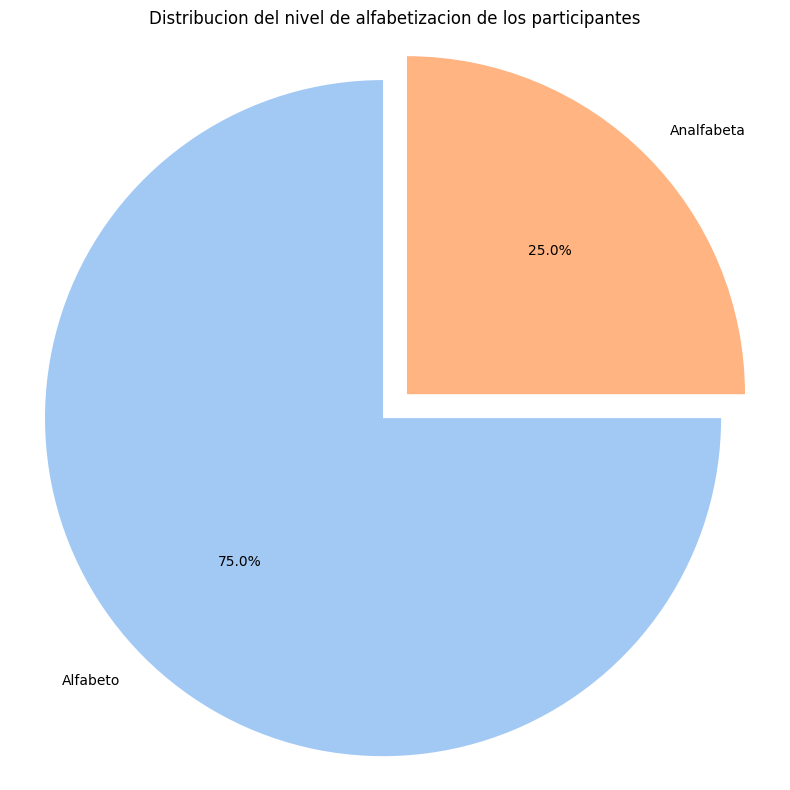

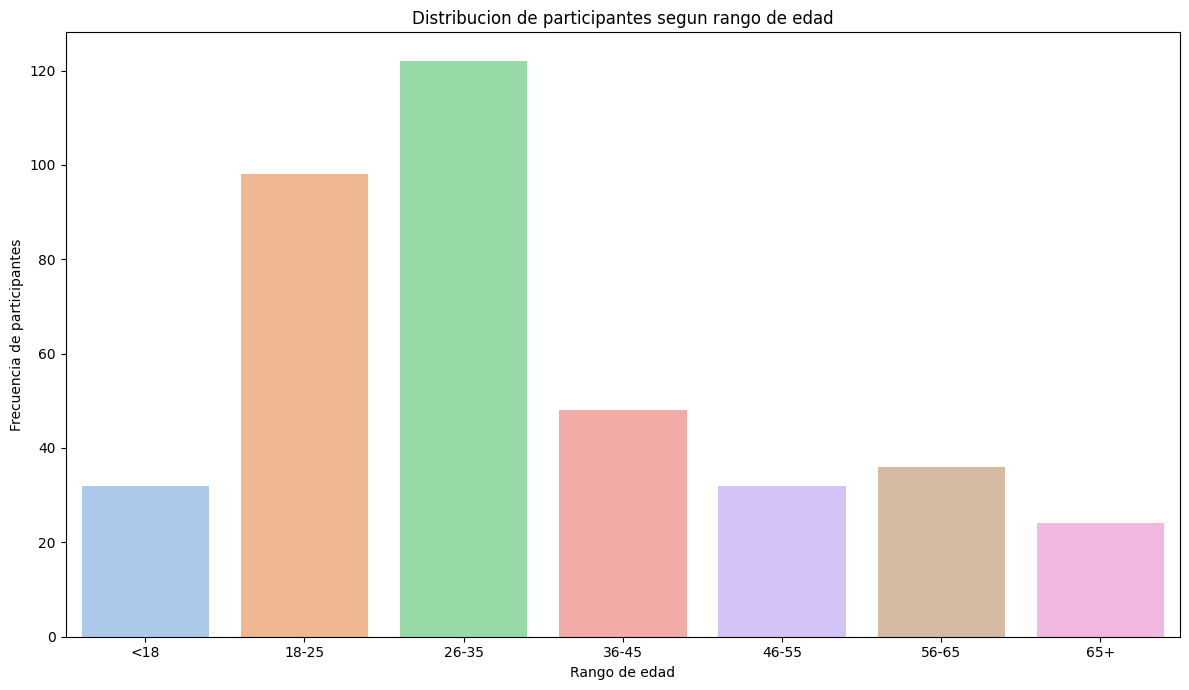

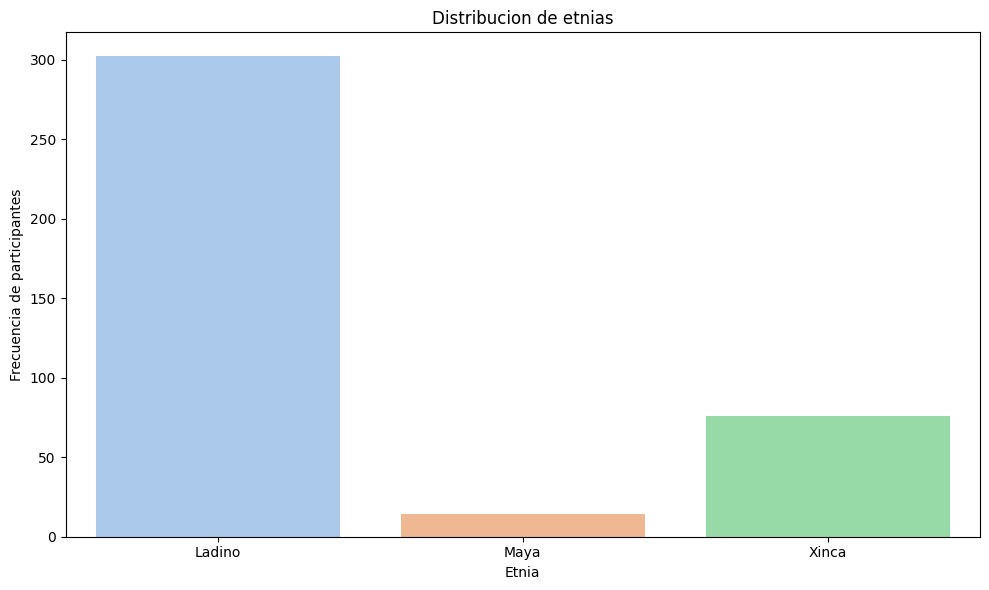

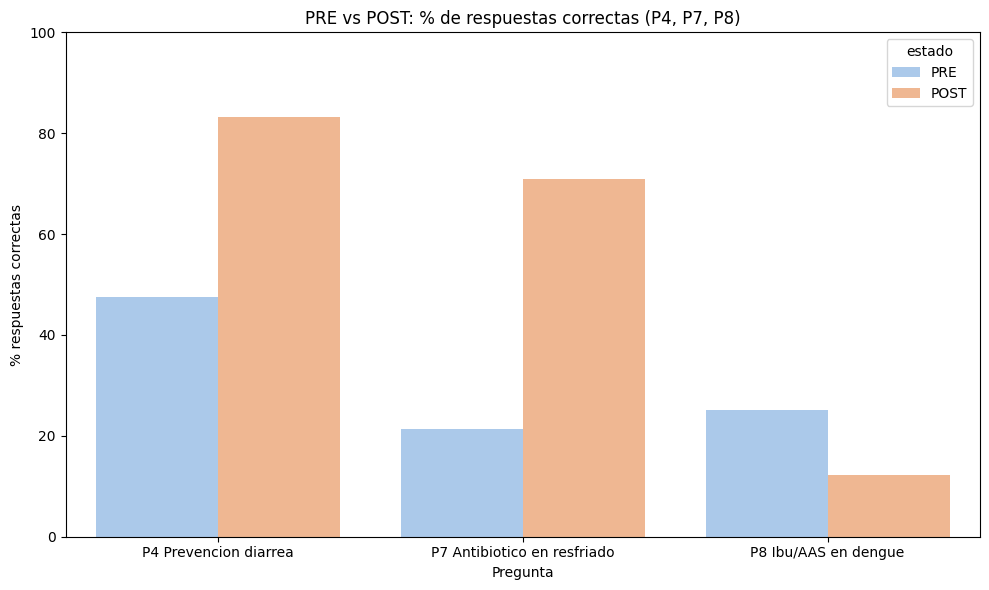

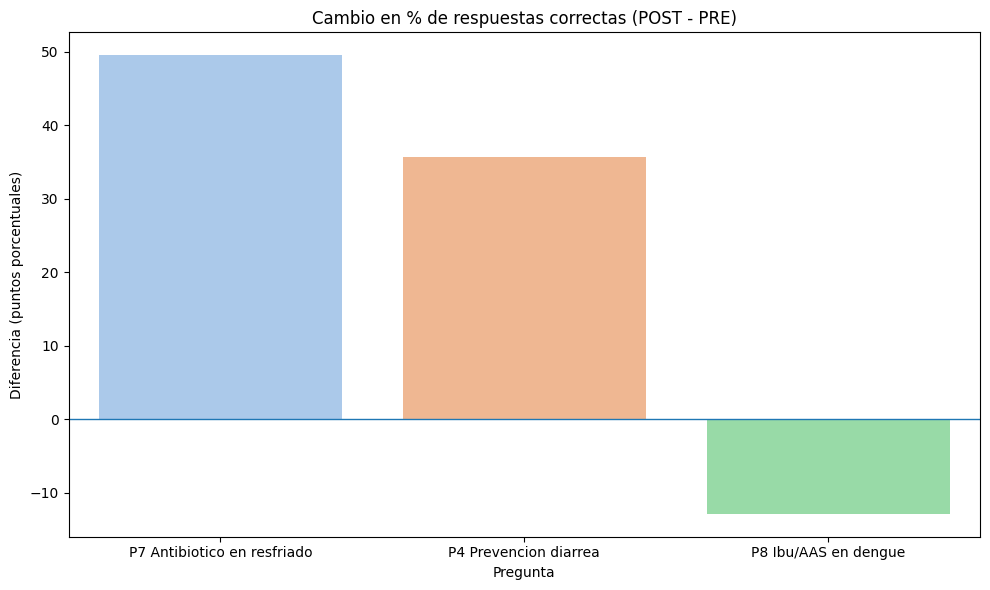

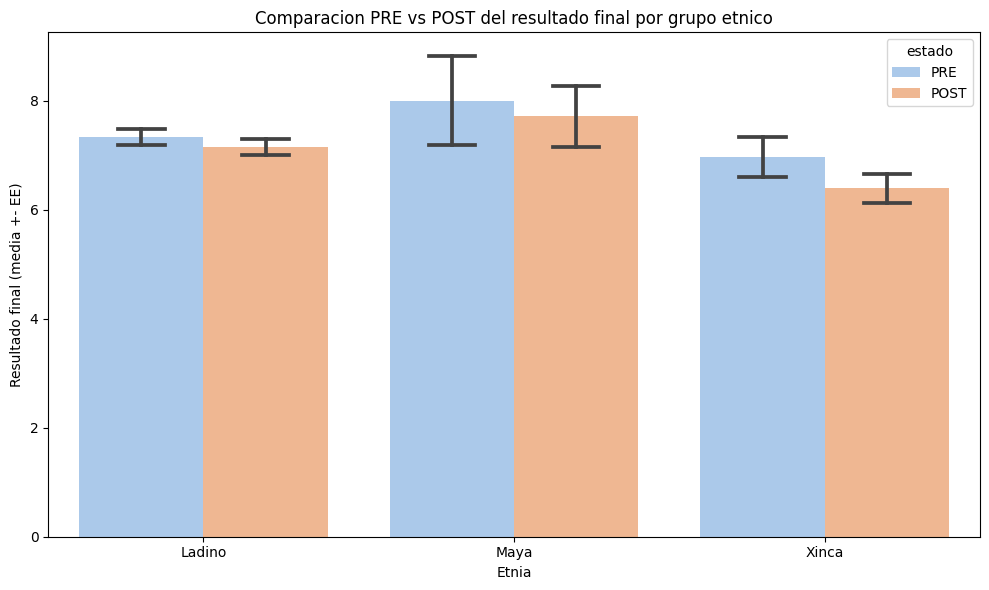

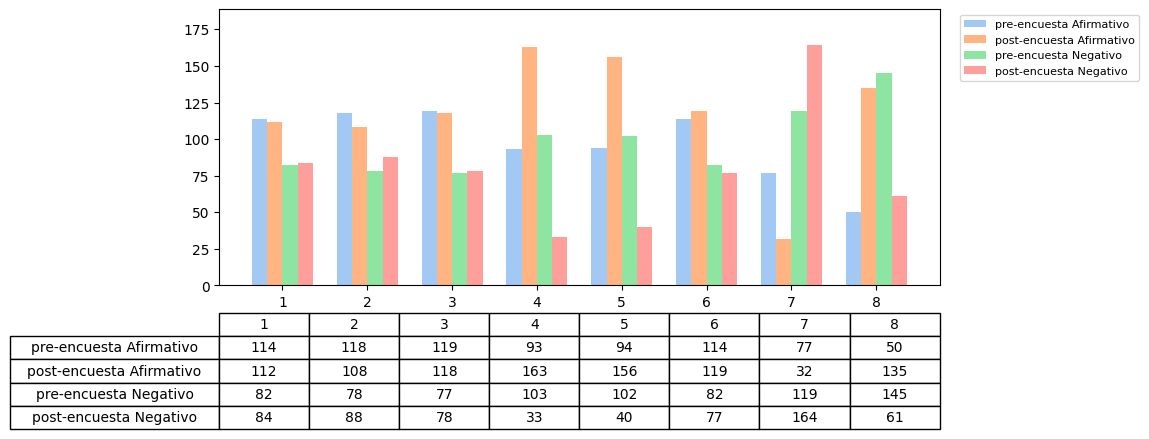

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Preparacion general
# -----------------------------
df_fix = resultados_total.copy()
df_fix["estado"] = df_fix["estado"].astype(str).str.strip().str.upper()

# -----------------------------
# 1) Grafica de pastel (alfabetizacion)
# -----------------------------
literacy_counts = pd.to_numeric(df_fix["analfabeta"], errors="coerce").dropna().astype(int).value_counts()
literacy_counts = literacy_counts.sort_index()

literacy_labels = ["Alfabeto" if x == 0 else "Analfabeta" for x in literacy_counts.index]
plt.figure(figsize=(8, 8))
plt.pie(
    literacy_counts.values,
    labels=literacy_labels,
    colors=sns.color_palette("pastel", n_colors=len(literacy_counts)),
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05] * len(literacy_counts)
)
plt.title("Distribucion del nivel de alfabetizacion de los participantes")
plt.axis("equal")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "analfabetismo_pie_chart_ajustado.png"), dpi=300, bbox_inches="tight")
# plt.show()

# -----------------------------
# 2) Edad por rangos (titulo + eje Y)
# -----------------------------
bins = [0, 17, 25, 35, 45, 55, 65, 100]
labels = ["<18", "18-25", "26-35", "36-45", "46-55", "56-65", "65+"]

df_fix["Rango_Edad"] = pd.cut(pd.to_numeric(df_fix["EDAD"], errors="coerce"), bins=bins, labels=labels, right=False)

plt.figure(figsize=(12, 7))
sns.countplot(data=df_fix, x="Rango_Edad", palette="pastel", order=labels)
plt.title("Distribucion de participantes segun rango de edad")
plt.xlabel("Rango de edad")
plt.ylabel("Frecuencia de participantes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "edad_histograma_rangos_ajustado.png"), dpi=300, bbox_inches="tight")
# plt.show()

# -----------------------------
# 3) Distribucion de etnias (1,2,4)
# -----------------------------
etnia_map = {1: "Ladino", 2: "Maya", 4: "Xinca"}
order_etnia = ["Ladino", "Maya", "Xinca"]

df_fix["ETNIA_NUM"] = pd.to_numeric(df_fix["ETNIA"], errors="coerce")
df_fix["ETNIA_NOMBRE"] = df_fix["ETNIA_NUM"].map(etnia_map)
df_etnia = df_fix[df_fix["ETNIA_NOMBRE"].notna()].copy()

plt.figure(figsize=(10, 6))
sns.countplot(data=df_etnia, x="ETNIA_NOMBRE", order=order_etnia, palette="pastel")
plt.title("Distribucion de etnias")
plt.xlabel("Etnia")
plt.ylabel("Frecuencia de participantes")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "etnia_distribution_count_ajustado.png"), dpi=300, bbox_inches="tight")
# plt.show()

# -----------------------------
# 4) PRE vs POST sin P6 (P4, P7, P8)
# -----------------------------
questions = ["P4", "P7", "P8"]
q_labels = {
    "P4": "P4 Prevencion diarrea",
    "P7": "P7 Antibiotico en resfriado",
    "P8": "P8 Ibu/AAS en dengue"
}
correct_key = {"P4": 1, "P7": 0, "P8": 0}

df_prepost = df_fix[df_fix["estado"].isin(["PRE", "POST"])].copy()
for q in questions:
    df_prepost[q] = pd.to_numeric(df_prepost[q], errors="coerce")

long = df_prepost.melt(id_vars=["estado"], value_vars=questions, var_name="pregunta", value_name="respuesta")
long["correcta"] = long.apply(lambda r: float(r["respuesta"] == correct_key[r["pregunta"]]) if pd.notna(r["respuesta"]) else np.nan, axis=1)

grp = long.groupby(["pregunta", "estado"], as_index=False)["correcta"].mean()
grp["porc_correctas"] = grp["correcta"] * 100
grp["pregunta_lbl"] = grp["pregunta"].map(q_labels)

order_lbl = [q_labels[q] for q in questions]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=grp,
    x="pregunta_lbl",
    y="porc_correctas",
    hue="estado",
    hue_order=["PRE", "POST"],
    order=order_lbl,
    palette="pastel",
    errorbar=None
)
plt.title("PRE vs POST: % de respuestas correctas (P4, P7, P8)")
plt.xlabel("Pregunta")
plt.ylabel("% respuestas correctas")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "pre_vs_post_porcentaje_correctas_P4_P7_P8_ajustado.png"), dpi=300, bbox_inches="tight")
# plt.show()

wide = grp.pivot(index="pregunta", columns="estado", values="porc_correctas")
wide["diff_pp"] = wide.get("POST", np.nan) - wide.get("PRE", np.nan)
diff_df = wide.reset_index()
diff_df["pregunta_lbl"] = diff_df["pregunta"].map(q_labels)
diff_df = diff_df.sort_values("diff_pp", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=diff_df, x="pregunta_lbl", y="diff_pp", palette="pastel", errorbar=None)
plt.axhline(0, linewidth=1)
plt.title("Cambio en % de respuestas correctas (POST - PRE)")
plt.xlabel("Pregunta")
plt.ylabel("Diferencia (puntos porcentuales)")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "diferencia_porcentual_correctas_POST_menos_PRE_P4_P7_P8_ajustado.png"), dpi=300, bbox_inches="tight")
# plt.show()

# -----------------------------
# 5) Resultado final PRE vs POST por etnia (1,2,4)
# -----------------------------
score_cols = ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8"]
for c in score_cols:
    df_fix[c] = pd.to_numeric(df_fix[c], errors="coerce")

df_fix["resultado_final"] = df_fix[score_cols].sum(axis=1)
df_final = df_fix[df_fix["estado"].isin(["PRE", "POST"]) & df_fix["ETNIA_NOMBRE"].notna()].copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_final,
    x="ETNIA_NOMBRE",
    y="resultado_final",
    hue="estado",
    order=order_etnia,
    hue_order=["PRE", "POST"],
    palette="pastel",
    errorbar="se",
    capsize=0.15
)
plt.title("Comparacion PRE vs POST del resultado final por grupo etnico")
plt.xlabel("Etnia")
plt.ylabel("Resultado final (media +- EE)")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "resultado_final_pre_vs_post_por_etnia_ajustado.png"), dpi=300, bbox_inches="tight")
# plt.show()

# -----------------------------
# 6) Correccion de afirmativo/negativo (P7)
# -----------------------------
QUESTIONS = ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8"]
AFIRMATIVO_FIX = {
    "P1": [1],
    "P2": [1],
    "P3": [1],
    "P4": [1],
    "P5": [1],
    "P6": [1],
    "P7": [1],  # correccion solicitada
    "P8": [1],
}

def tabla_afirmativo_negativo_fix(df_in: pd.DataFrame, questions, afirm_map) -> pd.DataFrame:
    dft = df_in.copy()
    dft["estado"] = dft["estado"].astype(str).str.strip().str.upper()
    dft = dft[dft["estado"].isin(["PRE", "POST"])]

    for q in questions:
        if q in dft.columns:
            dft[q] = pd.to_numeric(dft[q], errors="coerce")

    col_labels = [str(i) for i in range(1, len(questions) + 1)]
    filas = {
        "pre-encuesta Afirmativo": [],
        "post-encuesta Afirmativo": [],
        "pre-encuesta Negativo": [],
        "post-encuesta Negativo": [],
    }

    for q in questions:
        afirm = set(afirm_map.get(q, []))
        pre = dft[dft["estado"] == "PRE"][q].dropna()
        post = dft[dft["estado"] == "POST"][q].dropna()

        pre_af = int(pre.isin(afirm).sum())
        pre_ng = int((~pre.isin(afirm)).sum())
        post_af = int(post.isin(afirm).sum())
        post_ng = int((~post.isin(afirm)).sum())

        filas["pre-encuesta Afirmativo"].append(pre_af)
        filas["post-encuesta Afirmativo"].append(post_af)
        filas["pre-encuesta Negativo"].append(pre_ng)
        filas["post-encuesta Negativo"].append(post_ng)

    return pd.DataFrame(filas, index=col_labels).T

tabla_fix = tabla_afirmativo_negativo_fix(df_fix, QUESTIONS, AFIRMATIVO_FIX)
vals = tabla_fix.values
series = tabla_fix.index.tolist()
x = np.arange(tabla_fix.shape[1])
w = 0.18
colors = sns.color_palette("pastel", n_colors=len(series))

fig, ax = plt.subplots(figsize=(11, 6))
for i, name in enumerate(series):
    ax.bar(x + (i - 1.5) * w, vals[i], width=w, label=name, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(tabla_fix.columns.tolist())
ax.set_ylim(0, max(vals.flatten()) * 1.15)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

tbl = ax.table(
    cellText=vals,
    rowLabels=series,
    colLabels=tabla_fix.columns.tolist(),
    cellLoc="center",
    rowLoc="center",
    loc="bottom",
    bbox=[0.0, -0.52, 1.0, 0.42]
)

plt.subplots_adjust(bottom=0.42, right=0.78)
plt.savefig(os.path.join(OUT, "afirmativo_negativo_tabla_pastel_ajustado.png"), dpi=300, bbox_inches="tight")
# plt.show()

tabla_fix.to_excel(os.path.join(OUT, "tabla_afirmativo_negativo_ajustada.xlsx"), sheet_name="Tabla", index=True)

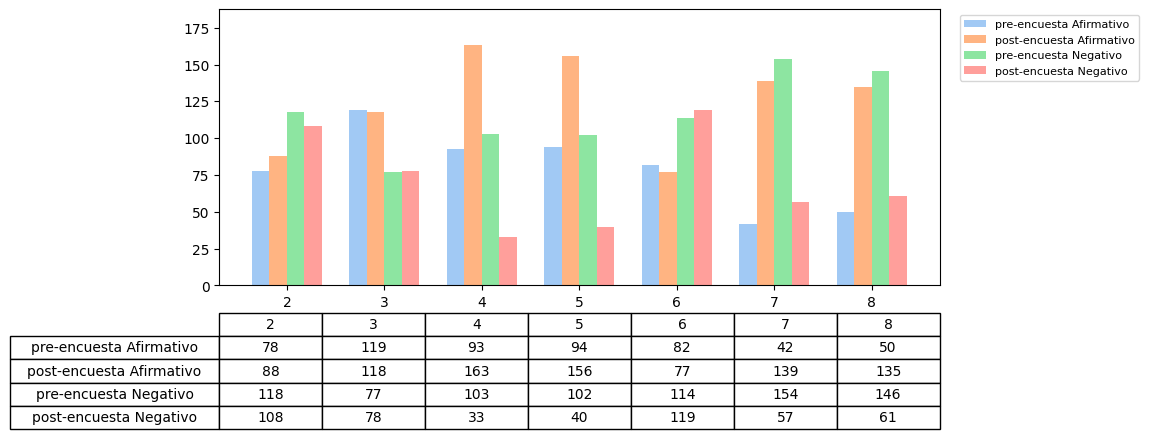

In [21]:
QUESTIONS = ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8"]
AFIRMATIVO_FIX = {
    "P1": [1],
    "P2": [1],
    "P3": [1],
    "P4": [1],
    "P5": [1],
    "P6": [1],
    "P7": [1],  # correccion solicitada
    "P8": [1],
}

def tabla_afirmativo_negativo_fix(df_in: pd.DataFrame, questions, afirm_map) -> pd.DataFrame:
    dft = df_in.copy()
    dft["estado"] = dft["estado"].astype(str).str.strip().str.upper()
    dft = dft[dft["estado"].isin(["PRE", "POST"])]

    for q in questions:
        if q in dft.columns:
            dft[q] = pd.to_numeric(dft[q], errors="coerce")

    col_labels = [str(i) for i in range(1, len(questions) + 1)]
    filas = {
        "pre-encuesta Afirmativo": [],
        "post-encuesta Afirmativo": [],
        "pre-encuesta Negativo": [],
        "post-encuesta Negativo": [],
    }

    for q in questions:
        afirm = set(afirm_map.get(q, []))
        pre = dft[dft["estado"] == "PRE"][q].dropna()
        post = dft[dft["estado"] == "POST"][q].dropna()

        pre_af = int(pre.isin(afirm).sum())
        pre_ng = int((~pre.isin(afirm)).sum())
        post_af = int(post.isin(afirm).sum())
        post_ng = int((~post.isin(afirm)).sum())

        filas["pre-encuesta Afirmativo"].append(pre_af)
        filas["post-encuesta Afirmativo"].append(post_af)
        filas["pre-encuesta Negativo"].append(pre_ng)
        filas["post-encuesta Negativo"].append(post_ng)

    return pd.DataFrame(filas, index=col_labels).T

tabla_fix = tabla_afirmativo_negativo_fix(df_fix, QUESTIONS, AFIRMATIVO_FIX)
tabla_fix = tabla_fix.drop(columns=["1"])
vals = tabla_fix.values
series = tabla_fix.index.tolist()
x = np.arange(tabla_fix.shape[1])
w = 0.18
colors = sns.color_palette("pastel", n_colors=len(series))

fig, ax = plt.subplots(figsize=(11, 6))
for i, name in enumerate(series):
    ax.bar(x + (i - 1.5) * w, vals[i], width=w, label=name, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(tabla_fix.columns.tolist())
ax.set_ylim(0, max(vals.flatten()) * 1.15)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

tbl = ax.table(
    cellText=vals,
    rowLabels=series,
    colLabels=tabla_fix.columns.tolist(),
    cellLoc="center",
    rowLoc="center",
    loc="bottom",
    bbox=[0.0, -0.52, 1.0, 0.42]
)

plt.subplots_adjust(bottom=0.42, right=0.78)
plt.savefig(os.path.join(OUT, "afirmativo_negativo_tabla_pastel_ajustado.png"), dpi=300, bbox_inches="tight")
plt.show()

## Prueba z

In [67]:
import pandas as pd
import numpy as np
from scipy import stats

dfp = resultados_total.copy()
dfp["estado"] = dfp["estado"].astype(str).str.strip().str.lower()
dfp["resultado_final"] = pd.to_numeric(dfp["resultado_final"], errors="coerce")
dfp = dfp[dfp["estado"].isin(["pre","post"])]

wide = dfp.pivot_table(index="ID", columns="estado", values="resultado_final", aggfunc="mean")
wide = wide.dropna(subset=["pre","post"]).copy()

d = wide["post"] - wide["pre"]
n = d.shape[0]

mean_d = d.mean()
sd_d = d.std(ddof=1)
se = sd_d / np.sqrt(n)

# Z estadístico (aprox normal)
z = mean_d / se

# p-value (dos colas)
p = 2 * (1 - stats.norm.cdf(abs(z)))

# IC 95% usando normal
zcrit = stats.norm.ppf(0.975)
ci_low, ci_high = mean_d - zcrit*se, mean_d + zcrit*se

print(f"n={n}")
print(f"Media(diff)= {mean_d:.4f}")
print(f"Z= {z:.4f} | p= {p:.6f}")
print(f"IC95% (normal) = [{ci_low:.4f}, {ci_high:.4f}]")

n=196
Media(diff)= 1.6224
Z= 16.4884 | p= 0.000000
IC95% (normal) = [1.4296, 1.8153]


In [66]:
pip install scipy

   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.3/37.3 MB 4.7 MB/s eta 0:00:08
   --- ------------------------------------ 3.4/37.3 MB 7.6 MB/s eta 0:00:05
   ----- ---------------------------------- 5.5/37.3 MB 8.3 MB/s eta 0:00:04
   -------- ------------------------------- 7.6/37.3 MB 8.4 MB/s eta 0:00:04
   ---------- ----------------------------- 10.0/37.3 MB 9.1 MB/s eta 0:00:04
   ------------- -------------------------- 12.6/37.3 MB 9.5 MB/s eta 0:00:03
   ---------------- ----------------------- 15.2/37.3 MB 9.9 MB/s eta 0:00:03
   ------------------ --------------------- 17.6/37.3 MB 10.1 MB/s eta 0:00:02
   --------------------- ------------------ 20.2/37.3 MB 10.3 MB/s eta 0:00:02
   ------------------------ --------------- 22.8/37.3 MB 10.5 MB/s eta 0:00:02
   --------------------------- ------------ 25.4/37.3 MB 10.6 MB/s eta 0:00:02
  

In [68]:
import numpy as np
import pandas as pd

dfp = resultados_total.copy()
dfp["estado"] = dfp["estado"].astype(str).str.strip().str.lower()
dfp["resultado_final"] = pd.to_numeric(dfp["resultado_final"], errors="coerce")
dfp = dfp[dfp["estado"].isin(["pre","post"])]

wide = dfp.pivot_table(index="ID", columns="estado", values="resultado_final", aggfunc="mean").dropna()
d = wide["post"] - wide["pre"]

print(d.describe())
print("Skew:", d.skew())
print("Kurtosis:", d.kurtosis())
print("Outliers |d-mean| > 3*sd:", ((d - d.mean()).abs() > 3*d.std(ddof=1)).sum())

# % que mejoran / empeoran / igual
print("Mejoran:", (d>0).mean(), "Empeoran:", (d<0).mean(), "Igual:", (d==0).mean())

count    196.000000
mean       1.622449
std        1.377588
min       -2.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        5.000000
dtype: float64
Skew: -0.06797737026655754
Kurtosis: -0.24244638402226215
Outliers |d-mean| > 3*sd: 0
Mejoran: 0.7857142857142857 Empeoran: 0.07142857142857142 Igual: 0.14285714285714285


In [69]:
from scipy import stats
w = stats.wilcoxon(wide["post"], wide["pre"], zero_method="wilcox", alternative="two-sided", mode="auto")
print(w)

WilcoxonResult(statistic=np.float64(452.0), pvalue=np.float64(1.581146763687824e-26))


Se compararon los puntajes antes y después de la capacitación en 196 participantes (medición pareada). Se observó un incremento promedio de 0.27 puntos (post−pre), con evidencia estadística de diferencia respecto a 0 (z = 2.44, p = 0.0146; IC95% [0.05, 0.49]). Un análisis no paramétrico robusto (Wilcoxon signed-rank) confirmó el hallazgo (p = 0.0136). En términos prácticos, el efecto es pequeño y la dirección del cambio es positiva.

# tabla final

In [70]:
import os
import numpy as np
import pandas as pd
from scipy import stats

# =========================
# Configuración (AJUSTA SOLO ESTO)
# =========================
id_col = "ID"
estado_col = "estado"
score_col = "resultado_final"
mu0_muestra2 = 67  # H0 para one-sample t test (como en tu imagen)

# Filtros:
# - Si no filtras, usa todos.
# - Ejemplo: df["Lugar"].isin(["Hospital X", "Hospital Y"])
# - Ejemplo: df["SEXO"] == 1
filtro_muestra1 = None
filtro_muestra2 = None

# Archivo de salida
out_dir = OUT if "OUT" in globals() else "outputs"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "anexo13_calculado_con_tus_datos.xlsx")

# =========================
# Preparación base (igual lógica de tu EDA)
# =========================
df = resultados_total.copy()
df[estado_col] = df[estado_col].astype(str).str.strip().str.lower()
if score_col not in df.columns:
    # por si no existiera, lo reconstruye como en tu notebook
    df["P7"] = np.where((df["P7"] == 2) | (df["P7"] == 0), 0, 1)
    df[score_col] = df[["P1","P2","P3","P4","P5","P6","P7","P8"]].apply(pd.to_numeric, errors="coerce").sum(axis=1)

df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
df = df[df[estado_col].isin(["pre", "post"])].copy()

# =========================
# MUESTRA 1: t pareada (formato tipo Excel)
# =========================
df_m1 = df.copy() if filtro_muestra1 is None else df[filtro_muestra1].copy()

wide1 = (
    df_m1.pivot_table(index=id_col, columns=estado_col, values=score_col, aggfunc="mean")
    .dropna(subset=["pre", "post"])
    .copy()
)

pre = wide1["pre"]
post = wide1["post"]
n = len(wide1)
dfree = n - 1

t_stat, p_two = stats.ttest_rel(pre, post, nan_policy="omit")  # pre - post
corr = pre.corr(post)

p_one = stats.t.cdf(t_stat, df=dfree) if dfree > 0 else np.nan
tcrit_one = stats.t.ppf(0.95, df=dfree) if dfree > 0 else np.nan
tcrit_two = stats.t.ppf(0.975, df=dfree) if dfree > 0 else np.nan

tabla_m1 = pd.DataFrame({
    "Indicador": [
        "Media", "Varianza", "Observaciones",
        "Coeficiente de correlación de Pearson",
        "Diferencia hipotética de las medias",
        "Grados de libertad",
        "Estadístico t",
        "P(T<=t) una cola",
        "Valor crítico de t (una cola)",
        "P(T<=t) dos colas",
        "Valor crítico de t (dos colas)"
    ],
    "pre": [
        pre.mean(), pre.var(ddof=1), n,
        corr, 0, dfree, t_stat, p_one, tcrit_one, p_two, tcrit_two
    ],
    "post": [
        post.mean(), post.var(ddof=1), n,
        np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
    ]
})

# =========================
# MUESTRA 2: one-sample t test (sobre POST)
# =========================
df_m2 = df.copy() if filtro_muestra2 is None else df[filtro_muestra2].copy()
x = df_m2.loc[df_m2[estado_col] == "post", score_col].dropna().astype(float)

n2 = x.shape[0]
mean2 = x.mean() if n2 > 0 else np.nan
sd2 = x.std(ddof=1) if n2 > 1 else np.nan
se2 = sd2 / np.sqrt(n2) if n2 > 1 else np.nan
df2 = n2 - 1
t2 = (mean2 - mu0_muestra2) / se2 if (n2 > 1 and se2 > 0) else np.nan

if n2 > 1 and np.isfinite(t2):
    p_lt = stats.t.cdf(t2, df=df2)                  # Ha: mean < mu0
    p_neq = 2 * (1 - stats.t.cdf(abs(t2), df=df2))  # Ha: mean != mu0
    p_gt = 1 - stats.t.cdf(t2, df=df2)              # Ha: mean > mu0
    tcrit = stats.t.ppf(0.975, df=df2)
    ci_low = mean2 - tcrit * se2
    ci_high = mean2 + tcrit * se2
else:
    p_lt = p_neq = p_gt = ci_low = ci_high = np.nan

tabla_m2 = pd.DataFrame({
    "Variable": [f"{score_col} (post)"],
    "Obs": [n2],
    "Mean": [mean2],
    "Std. Err.": [se2],
    "Std. Dev.": [sd2],
    "[95% Conf. Interval] Low": [ci_low],
    "[95% Conf. Interval] High": [ci_high],
    "t": [t2],
    "degrees of freedom": [df2],
    "H0: mean =": [mu0_muestra2],
    "Pr(T < t)": [p_lt],
    "Pr(|T| > |t|)": [p_neq],
    "Pr(T > t)": [p_gt]
})

# =========================
# Exportar Excel
# =========================
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    tabla_m1.to_excel(writer, sheet_name="Muestra_1_t_pareada", index=False)
    tabla_m2.to_excel(writer, sheet_name="Muestra_2_one_sample_t", index=False)

print(f"Excel guardado en: {out_path}")
print(f"Muestra 1 (pareada): n={n}")
print(f"Muestra 2 (one-sample, post): n={n2}")


Excel guardado en: C:\Users\rodri\OneDrive\Documentos\EDA_Tesis\outputs\anexo13_calculado_con_tus_datos.xlsx
Muestra 1 (pareada): n=196
Muestra 2 (one-sample, post): n=196
